# 📓 Cas d'usage IA — [Orientation et tri multimodal des demandeurs d'emploi par l'Intelligence Artificielle]

**Auteur·e** : `Nicolas H`  
**Promo** : ATOS Atlas IA — Parcours 2 (Pros IT)  
**Date début** : `05/09/2026`  
**Dernière mise à jour** : `02/10/2026`

---


## 0. Imports & configuration

🎯 Centraliser les imports et la configuration reproductible.  
💡 Cette section centralise l'ensemble des imports, la configuration du projet et les paramètres de reproductibilité afin de garantir un environnement d'exécution cohérent et traçable pour toutes les expérimentations.

In [1]:
# ==========================================================
# Imports standards
# ==========================================================

import os
import importlib
import sys
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import requests

# ==========================================================
# Imports ML
# ==========================================================

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    make_scorer,
    recall_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

# ==========================================================
# Modèles
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

# ==========================================================
# Industrialisation
# ==========================================================

import joblib
import mlflow
from mlflow import MlflowClient

# ==========================================================
# Affichage
# ==========================================================

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

# ==========================================================
# Configuration du projet
# ==========================================================

# Le notebook s'exécute depuis notebooks/
ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    system_cfg,
    project_cfg,
    training_cfg,
    business_cfg,
)

# ==========================================================
# Reproductibilité
# ==========================================================

np.random.seed(training_cfg.SEED)

# ==========================================================
# Modules du projet
# ==========================================================

from src import benchmark as B
from src import train_model as TM


# ==========================================================
# Variables 
# ==========================================================

TARGET = project_cfg.TARGET

FEAT_NUM = project_cfg.FEATURES_NUMERIC
FEAT_CAT = project_cfg.FEATURES_CATEGORICAL
FEAT_BIN = project_cfg.FEATURES_BINARY
FEAT_TXT = project_cfg.FEATURE_TEXT
FEAT_SEN = project_cfg.FEATURES_SENSITIVE

DATASET_PATH = system_cfg.DATASET_PATH

TEST_SIZE = training_cfg.TEST_SIZE
SEED = training_cfg.SEED

N_SPLITS = training_cfg.N_SPLITS

MIN_ACC = business_cfg.MIN_ACCURACY
MIN_F1 = business_cfg.MIN_MACRO_F1
MIN_RECALL_R2 = business_cfg.MIN_RECALL_CLASS_2


# ==========================================================
# Vérification configuration
# ==========================================================

print("=" * 60)
print("Atlas CISIA")
print("=" * 60)

print(f"Racine projet           : {ROOT}")
print(f"Dataset                 : {DATASET_PATH}")

print(f"Nb Features numériques  : {len(FEAT_NUM)}")
print(f"Nb Features catég.      : {len(FEAT_CAT)}")
print(f"Nb Features binaires    : {len(FEAT_BIN)}")
print(f"Nb Feature texte        : 1")
print(f"Target                  : {TARGET}")

print(f"Seed                    : {training_cfg.SEED}")
print(f"Test size               : {training_cfg.TEST_SIZE}")
print(f"CV folds                : {training_cfg.N_SPLITS}")
print(f"MLflow URI              : {system_cfg.MLFLOW_TRACKING_URI}")
print(f"MLflow experiment       : {system_cfg.MLFLOW_EXPERIMENT_NAME}")

print("=" * 60)

# ==========================================================
# Désactivation des proxies pour MLflow local
# ==========================================================

if system_cfg.DISABLE_PROXY:

    os.environ.pop("HTTP_PROXY", None)
    os.environ.pop("HTTPS_PROXY", None)

    os.environ.pop("http_proxy", None)
    os.environ.pop("https_proxy", None)

    os.environ["NO_PROXY"] = "localhost,127.0.0.1"

    print("✅ Proxies HTTP/HTTPS désactivés")

Atlas CISIA
Racine projet           : /home/a453784/simplon-briefs/Atlas_CISIA_Exam
Dataset                 : data/dataset_trajectoire_emploi.csv
Nb Features numériques  : 2
Nb Features catég.      : 3
Nb Features binaires    : 2
Nb Feature texte        : 1
Target                  : classe_retour_emploi
Seed                    : 42
Test size               : 0.2
CV folds                : 5
MLflow URI              : http://localhost:5000
MLflow experiment       : Employment_Prediction
✅ Proxies HTTP/HTTPS désactivés


## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** sur tout environnement et par une tierse partie.


In [2]:
from datetime import datetime
import subprocess
import sys

session_date = datetime.now().isoformat(timespec="minutes")

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"]
    ).decode().strip()
except Exception:
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")

Date session : 2026-10-04T20:44
Python       : 3.14.4
NumPy        : 2.5.2
Pandas       : 2.3.3
Git commit   : caab3e4


---
## 1. Cadrage métier & problème

🎯 **Cette section cherche à répondre à plusieurs questions** :

- Qui est le client ? Quel est son besoin métier réel ?
- Qui sont les bénéficiaires directs et indirects de la solution ?
- Quel type de tâche IA (classification, régression, clustering, génération…) ?
- Quels critères de succès **côté métier** (pas seulement côté modèle) ?
- Quels risques éthiques, réglementaires, de biais sont pressentis ?
- Quel cadre réglementaire s'applique (RGPD, AI Act, secteur régulé) ?


### 1.1 Contexte client

Le client est un acteur public majeur chargé de l'accompagnement des demandeurs d'emploi et de leur retour à l'emploi. Les conseillers réalisent des entretiens d'orientation afin d'évaluer la situation des usagers et de définir le niveau d'accompagnement le plus adapté. Face à un volume important de dossiers et à la nécessité d'allouer efficacement les ressources d'accompagnement, l'organisme souhaite disposer d'un outil d'aide à la décision capable d'estimer le risque de chômage de longue durée dès le premier entretien. Le projet consiste à exploiter des données administratives, socio-professionnelles, géographiques et textuelles afin d'automatiser partiellement cette évaluation. Le recours à l'intelligence artificielle vise à améliorer la rapidité, l'homogénéité et la fiabilité des décisions d'orientation tout en renforçant la détection précoce des situations nécessitant un accompagnement renforcé

### 1.2 Énoncé du problème IA

La problématique IA peut être formulé comme une tâche de classification supervisée multiclasse.
L'objectif est de :
> Prédire la classe de retour à l'emploi d'un demandeur d'emploi à partir d'informations tabulaires (âge, diplôme, ancienneté, statut administratif, données géographiques, etc.) et d'une synthèse textuelle issue du premier entretien.

La variable cible comporte trois catégories :

| Classe | Signification |
|---|---|
| 0 | Retour à l'emploi rapide (< 6 mois) | 
| 1 | Retour à l'emploi moyen (6 à 12 mois) | 
| 2 | Risque de chômage longue durée (> 12 mois) | 

Le système devra attribuer automatiquement l'une de ces trois classes à chaque nouvel usager

### 1.3 Bénéficiaires & impacts

**Bénéficiaires directs**
- Conseillers de l'agence : Les conseillers utilisent la solution comme un outil d'aide à la décision lors des entretiens d'orientation. Le modèle fournit une estimation du niveau de risque afin d'aider à identifier rapidement les usagers nécessitant un accompagnement renforcé.

- Managers et responsables des politiques d'emploi : Les responsables opérationnels peuvent s'appuyer sur les prédictions produites pour optimiser l'allocation des ressources et le pilotage des dispositifs d'accompagnement.

**Bénéficiaires indirects**
- Demandeurs d'emploi : Les usagers bénéficient d'une orientation potentiellement plus rapide et plus adaptée à leur situation. Une meilleure détection des situations à risque permet d'accéder plus tôt à des dispositifs d'accompagnement spécifiques.
- Collectivité publique : Une amélioration de l'efficacité des dispositifs d'accompagnement peut contribuer à réduire les coûts associés au chômage de longue durée et à améliorer les résultats des politiques publiques de l'emploi.

**Impacts négatifs potentiels**
Une mauvaise classification peut conduire à une orientation inadaptée. Le risque le plus critique identifié est celui d'un usager relevant réellement de la classe 2 qui serait classé en classe 0, le privant ainsi d'un accompagnement renforcé.

### 1.4 Critères de succès

Le succès du projet peut être évalué selon plusieurs dimensions complémentaires : métier, technique, et opérationnel. Les objectifs initiaux pourront être ajustés après l'analyse exploratoire des données afin de tenir compte de la qualité des données, du déséquilibre éventuel des classes et des limites observées lors des premières expérimentations.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|--------|----------|----------|----------|----------|
| Métier | Détecter précocement les demandeurs d'emploi à risque de chômage longue durée (classe 2) | Identifier la majorité des situations à risque | À compléter | Dépend du poids réel de la classe 2 dans le dataset |
| Métier | Réduire les erreurs critiques Classe 2 → Classe 0 | Niveau minimal d'erreurs | À compléter | Une sous-estimation du risque prive potentiellement l'usager d'un accompagnement renforcé |
| Métier | Homogénéiser les décisions d'orientation | Réduire la variabilité entre conseillers | À compléter | Le modèle doit fournir une aide à la décision cohérente |
| Technique | Accuracy globale | ≥ 80 % | À compléter | À confronter à la difficulté réelle du problème et au déséquilibre des classes |
| Technique | Macro F1-score | ≥ 0,75 | À compléter | Métrique plus adaptée à une classification multiclasse potentiellement déséquilibrée |
| Technique | Recall de la classe 2 | ≥ 80 % | À compléter | Métrique prioritaire compte tenu du coût métier des faux négatifs |
| Technique | Validation croisée stratifiée stable | Écart-type faible entre folds | À compléter | Garantit la robustesse du modèle et limite le surapprentissage |
| Opérationnel | Temps de prédiction par dossier | < 1 seconde | À compléter | Compatible avec une utilisation pendant l'entretien |


> **Critère métier prioritaire :** minimiser les erreurs de type Classe 2 → Classe 0, c'est-à-dire les situations où un demandeur d'emploi à risque de chômage longue durée serait considéré à tort comme faiblement exposé.*


### 1.5 Risques éthiques & réglementaires anticipés

**Utilisation de données sensibles**
Le jeu de données contient une variable explicitement identifiée comme sensible : *nationalité hors Union Européenne*. Son utilisation peut introduire des biais discriminatoires et devra doit faire l'objet d'une analyse spécifique conformément aux exigences du RGPD et à l'approche éthique demandée dans le sujet.

**Risque de discrimination algorithmique**
Le modèle pourrait apprendre des corrélations historiques défavorables envers certaines catégories de population et reproduire ou amplifier des biais existants. Une comparaison avec et sans variables sensibles doit être réalisée afin de mesurer cet impact.

**Transparence des décisions**
Les prédictions influencent des décisions d'orientation pouvant avoir des conséquences importantes pour les usagers. Il est donc nécessaire de fournir des éléments d'explicabilité permettant aux conseillers de comprendre les résultats proposés par le modèle.

**Protection des données personnelles**
Les données utilisées concernent des personnes physiques et contiennent des informations socio-professionnelles ainsi que des verbatims d'entretien. Leur traitement doit respecter les principes de minimisation, de sécurité, de traçabilité et de confidentialité prévus par le RGPD.

**Cadre réglementaire européen de l'IA**
Le système développé constitue une aide à la décision dans un contexte de service public impliquant des personnes physiques. À ce titre, une analyse préliminaire du niveau de risque au regard de l'AI Act doit être réalisée. Quelle que soit la classification finale retenue, les principes de supervision humaine, de transparence, de traçabilité et d'explicatibilité doivent être pris en compte dès la conception de la solution.


### 1.6 📝 Synthèse cadrage

Le projet vise à développer un système d'intelligence artificielle capable de prédire le délai probable de retour à l'emploi d'un demandeur d'emploi à partir de données administratives, socio-professionnelles, géographiques et textuelles. La problématique est modélisée sous la forme d'une **classification supervisée à trois classes** : retour rapide, retour moyen ou risque de chômage longue durée. Le principal critère de succès consiste à réduire les erreurs critiques conduisant à sous-estimer le niveau de risque d'un usager en difficulté. Le risque éthique majeur identifié concerne l'utilisation de variables sensibles susceptibles d'introduire des biais discriminatoires dans les décisions d'orientation.


---
## 2. Identification & acquisition des données

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| Agence nat. pour l'emploi | CSV | 2 500 | CSV, sép "*virgule*" | copié dans /data | *inconnue* |


### 2.2 Chargement du dataset

In [3]:
# 2.2 Chargement

dataset_path = ROOT / system_cfg.DATASET_PATH

df = pd.read_csv(dataset_path)

print(f"Dataset : {dataset_path}")
print(f"Nombre de lignes    : {df.shape,}")
print(f"Nombre de colonnes : {df.shape[1]}")

df.columns.tolist()

Dataset : /home/a453784/simplon-briefs/Atlas_CISIA_Exam/data/dataset_trajectoire_emploi.csv
Nombre de lignes    : ((2500, 10),)
Nombre de colonnes : 10


['usager_id',
 'age',
 'niveau_diplome',
 'anciennete_poste_ans',
 'code_rome_vise',
 'code_insee_commune',
 'est_allocataire',
 'nationalite_hors_ue',
 'synthese_entretien',
 'classe_retour_emploi']

### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | *Identifiant unique du demandeur d'emploi* | num/cat | *[ID_0000]* | ❌ | ❌ |
| `age` | *Âge de l'usager en années* | num | *[> 18]* | ❌ | ✅ |
| `niveau_diplome` | *Plus haut niveau de diplôme obtenu* | cat | *Sans diplôme, Bac, Bac+2, Bac+5* | ❌ | ❌ |
| `anciennete_poste_ans` | *Nombre d'années d'expérience dans le dernier emploi occupé* | num | *[min-max ou modalités]* | ❌ | ❌ |
| `code_rome_vise` | *Code du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager* | cat | *[5 caractères]* | ❌ | ❌ |
| `code_insee_commune` | *Code officiel géographique INSEE de la commune de résidence* | cat | *[5 digits]* | ❌ | ✅ |
| `est_allocataire` | *Statut d'indemnisation de l'usager* | cat | *[1 (Oui), 0 (Non)]* | ❌ | ❌ |
| `nationalite_hors_ue` | *Variable sensible* | cat | *[1 (hors Union Européenne), 0 (UE)]* | ❌ | ✅ |
| `synthèse_entretien` | *Texte libre contenant les notes textuelles du conseiller lors de l'entretien* | texte | *[texte libre]* | ❌ | ❌ |
| `classe_retour_emploi` | Variable cible : 0 (Rapide < 6m), 1 (Moyen 6-12m), 2 (Risque de longue durée > 12m) | cible | *[0,1,2]* | ✅ | ❌ |

### 2.4 📝 Synthèse acquisition

Le jeu de données contient des variables numériques, catégorielles et textuelles permettant d'alimenter un modèle de classification multiclasse.

La présence d'une variable sensible ("nationalité hors UE") nécessite une analyse éthique spécifique. Cette variable peut en effet être source de biais ou de discrimination indirecte. Un entrainement sans cette variable fera l'objet d'un scénario alternatif.

Les prochaines étapes consistent à réaliser l'analyse exploratoire approfondie (EDA), à étudier la qualité des données et à identifier les variables les plus informatives pour la prédiction.


---
## 3. Exploration & analyse des données (EDA)

> 🎯 Comprendre la donnée **avant** de la transformer. Détecter manquants, doublons, aberrations, déséquilibres, biais.

L'analyse exploratoire est conduite selon une démarche progressive consistant à évaluer la qualité du jeu de données, à caractériser les variables individuellement puis à étudier leurs interactions afin de mieux comprendre les mécanismes associés au retour à l'emploi et d'orienter les étapes ultérieures de préparation et de modélisation. L'objectif de cette analyse exploratoire est de répondre aux questions suivantes :

- Les données sont-elles complètes et exploitables ?
- La variable cible présente-t-elle un déséquilibre susceptible d'impacter l'apprentissage ?
- Quelles sont les caractéristiques des demandeurs d'emploi selon leur classe de retour à l'emploi ?
- Existe-t-il des variables particulièrement discriminantes pour la prédiction ?
- Certaines variables présentent-elles des risques de biais ou de fuite d'information ?

Les enseignements issus de cette phase permettront de : 
- sélectionner les variables pertinentes,
- définir la stratégie de préparation des données, 
- orienter les choix de modélisation.


### 3.1 Premier coup d'œil

In [4]:
print("— info —")
print(df.info())
print()

— info —
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB
None



In [5]:
print("— desc —")
df.describe(include="all")

— desc —


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
count,2500,2378.000000,2416,2500.000000,2500,2500,2456.000000,2500.000000,2419,2500.000000
unique,2500,NaN,4,NaN,50,2407,NaN,NaN,9,NaN
top,ID_0000,NaN,Bac,NaN,H1206,46283,NaN,NaN,Compétences à réactualiser sur les outils numé...,NaN
freq,1,NaN,966,NaN,71,3,NaN,NaN,338,NaN
mean,NaN,40.566442,NaN,2.971600,NaN,NaN,0.595684,0.118000,NaN,0.806400
std,NaN,13.225242,NaN,2.979548,NaN,NaN,0.490859,0.322673,NaN,0.719671
min,NaN,18.000000,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
25%,NaN,29.000000,NaN,0.800000,NaN,NaN,0.000000,0.000000,NaN,0.000000
50%,NaN,41.000000,NaN,2.000000,NaN,NaN,1.000000,0.000000,NaN,1.000000
75%,NaN,52.000000,NaN,4.100000,NaN,NaN,1.000000,0.000000,NaN,1.000000


In [6]:
print("— head —")
df.head()

— head —


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


🔍 **Observations** : 
> Le dataset contient 2 500 observations mêlant variables numériques, catégorielles et textuelles. Cette structure est cohérente avec la problématique métier. On note que certaines des variables contiennent valeurs manquantes à traiter et la présence d'une variable sensible (`nationalite_hors_ue`) qui nécessitera une analyse spécifique dans le cadre de l'évaluation éthique et réglementaire du projet.

### 3.2 Qualité des données : manquants, doublons, valeurs aberrantes

In [7]:
print("— Valeurs manquantes —")

missing_df = pd.DataFrame({
    "nb_manquants": df.isna().sum(),
    "pct_manquants": round(df.isna().mean() * 100, 2)
})

missing_df = missing_df.sort_values(
    by="pct_manquants",
    ascending=False
)
print(missing_df)
print()

print("— Cardinalités des colonnes catégorielles —")

for col in ["age", "anciennete_poste_ans", "niveau_diplome", "code_rome_vise"]:
    print(f"{col:20s} {df[col].nunique():5d} modalités")
print()

print("— Doublons —")
nb_doublons = df.duplicated().sum()
if nb_doublons == 0:
    print("Aucun doublon")
else:
    print(f"{nb_doublons} doublon(s) trouvé(s)")


— Valeurs manquantes —
                      nb_manquants  pct_manquants
age                            122           4.88
niveau_diplome                  84           3.36
synthese_entretien              81           3.24
est_allocataire                 44           1.76
usager_id                        0           0.00
anciennete_poste_ans             0           0.00
code_insee_commune               0           0.00
code_rome_vise                   0           0.00
nationalite_hors_ue              0           0.00
classe_retour_emploi             0           0.00

— Cardinalités des colonnes catégorielles —
age                     46 modalités
anciennete_poste_ans   154 modalités
niveau_diplome           4 modalités
code_rome_vise          50 modalités

— Doublons —
Aucun doublon


🔍 **Observations :**
> L'analyse des valeurs manquantes montre que le jeu de données est globalement de bonne qualité. Seules quatre variables présentent des données absentes : `age (4,88 %)`, `niveau_diplome (3,36 %)`, `synthese_entretien (3,24 %)` et `est_allocataire (1,76 %)`. Toutes les autres variables, y compris la variable cible classe_retour_emploi, sont complètes.

> Le taux de valeurs manquantes reste faible pour l'ensemble des variables concernées (< 5 %). Ce niveau de complétude est satisfaisant et ne justifie pas la suppression de variables ni l'exclusion massive d'observations. La présence de valeurs manquantes dans l'âge, le niveau de diplôme et la synthèse d'entretien peut cependant affecter la qualité des prédictions, ces variables étant susceptibles d'apporter une information discriminante sur la classe de retour à l'emploi.

### 3.3 Distribution des variables (numériques + catégorielles)

Cette section vise à étudier la distribution des principales variables du jeu de données afin d'identifier d'éventuelles anomalies, asymétries, valeurs extrêmes ou déséquilibres susceptibles d'influencer les performances des modèles.

#### 3.3.1 Age

/tmp/ipykernel_730101/392913039.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


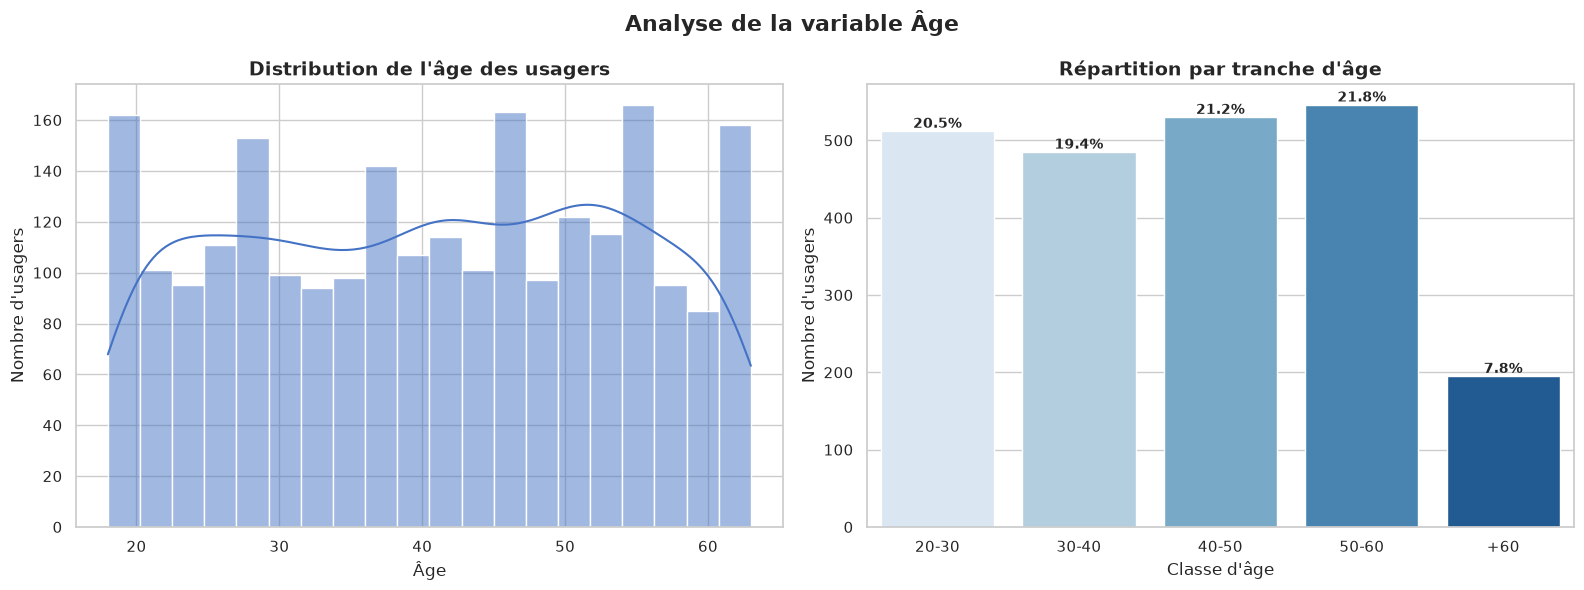

In [8]:
# ------------------------------------------------------------------
# Création des classes d'âge
# ------------------------------------------------------------------

df_plot = df.copy()

bins = [20, 30, 40, 50, 60, 100]
labels = ["20-30", "30-40", "40-50", "50-60", "+60"]

df_plot["tranche_age"] = pd.cut(
    df_plot["age"],
    bins=bins,
    labels=labels,
    right=False
)

# ------------------------------------------------------------------
# Paramètres graphiques
# ------------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6)
)

# ------------------------------------------------------------------
# Graphique 1 : distribution âge
# ------------------------------------------------------------------

sns.histplot(
    data=df_plot,
    x="age",
    bins=20,
    kde=True,
    color="#4472C4",
    ax=axes[0]
)

axes[0].set_title(
    "Distribution de l'âge des usagers",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Âge")
axes[0].set_ylabel("Nombre d'usagers")

# ------------------------------------------------------------------
# Graphique 2 : classes d'âge
# ------------------------------------------------------------------

ax = sns.countplot(
    data=df_plot,
    x="tranche_age",
    palette="Blues",
    ax=axes[1]
)

# Ajout des pourcentages
total = len(df_plot)

for bar in ax.patches:

    count = int(bar.get_height())
    pct = count / total * 100

    ax.annotate(
        f"{pct:.1f}%",
        (
            bar.get_x() + bar.get_width() / 2,
            count
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

axes[1].set_title(
    "Répartition par tranche d'âge",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Classe d'âge")
axes[1].set_ylabel("Nombre d'usagers")

# ------------------------------------------------------------------
# Titre global
# ------------------------------------------------------------------

fig.suptitle(
    "Analyse de la variable Âge",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()




🔍 **Observations** : 
> La distribution des âges permet d'identifier une population majoritairement ou minoritairement représentée dans le jeu de données.
> Aucune abération majeure n'est observée à ce stade (âges négatifs, valeurs irréalistes).
> La distribution est relativement équilibrée, il n'y a pas de sur ou sous repréentation d'age ou classe d'age en particulier (à l'excetion des +60 ans).

#### 3.3.2 Ancienneté poste 

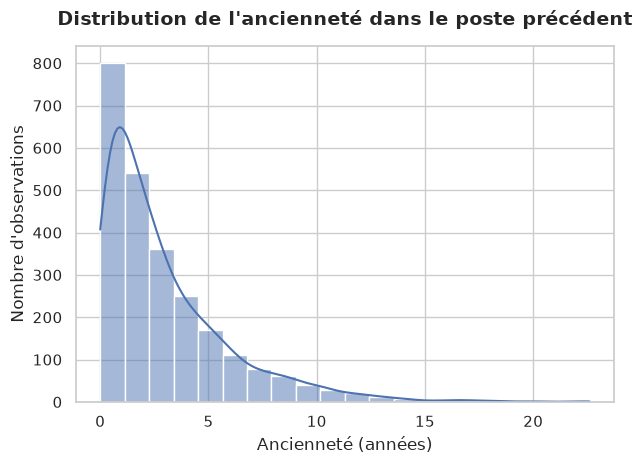

In [9]:
sns.histplot(
    data=df,
    x="anciennete_poste_ans",
    bins=20,
    kde=True
)

plt.title(
    "Distribution de l'ancienneté dans le poste précédent",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Ancienneté (années)")
plt.ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()



🔍 **Observations** : 
> Cette variable présente une distribution asymétrique, avec une concentration importante d'individus ayant une faible ancienneté et une faible proportion correspondant à des parcours professionnels plus stables.

#### 3.3.3 Niveau de diplome

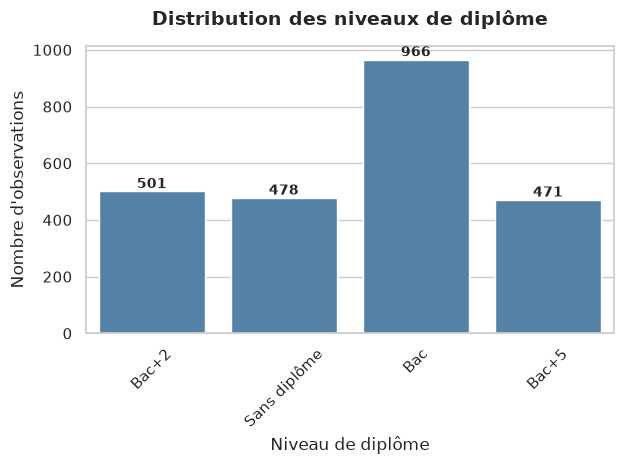

In [10]:
ax = sns.countplot(
    data=df,
    x="niveau_diplome",
    color="steelblue"
)

# Affichage des valeurs au-dessus des barres
for bar in ax.patches:
    hauteur = int(bar.get_height())

    ax.annotate(
        str(hauteur),
        (
            bar.get_x() + bar.get_width() / 2,
            hauteur
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(rotation=45)

plt.title(
    "Distribution des niveaux de diplôme",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.xlabel("Niveau de diplôme")
plt.ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

🔍 **Observation :**
> Le niveau Bac constitue une classe majoritaire par rapport aux autres classes.

#### 3.3.4 Longueur de la synthèse

<Axes: xlabel='longueur_synthese', ylabel='Count'>

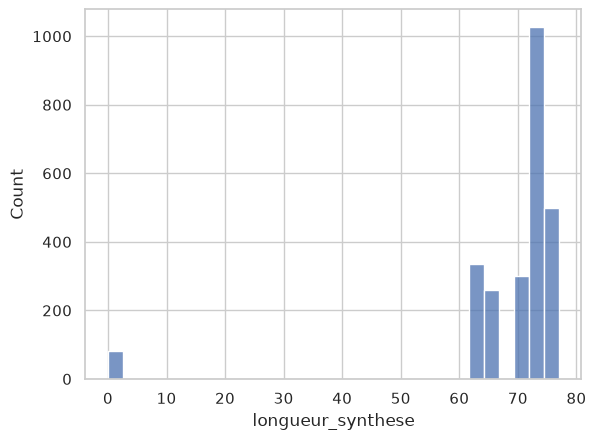

In [11]:
df["longueur_synthese"] = (
    df["synthese_entretien"]
    .fillna("")
    .str.len()
)

sns.histplot(
    data=df,
    x="longueur_synthese",
    bins=30
)


🔍 **Observations :**
> La grande majorité des observations disposent d'une synthèse composée d'environ 300 jusqu'à 1000 caractères.

### 3.4 Variable cible : équilibre des classes / distribution

/tmp/ipykernel_730101/1788006777.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


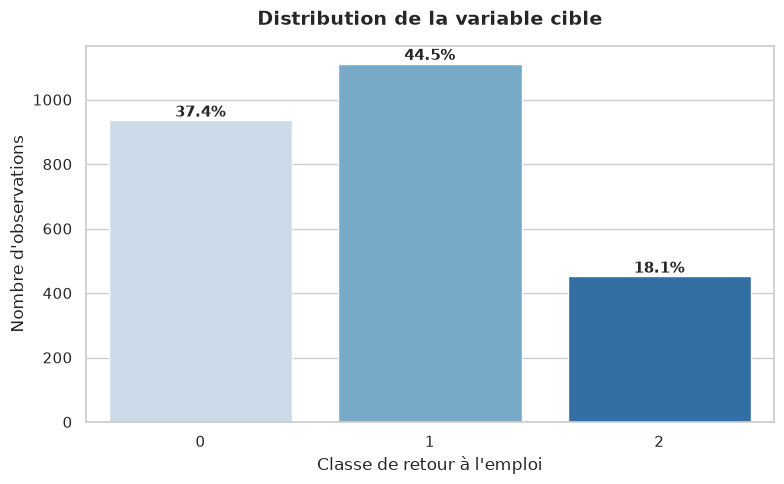

In [12]:
# Graphique de distribution de la classe

# Taille de la figure
plt.figure(figsize=(8, 5))

# Graphique
ax = sns.countplot(
    data=df,
    x="classe_retour_emploi",
    palette="Blues"
)

# Total pour calculer les pourcentages
total = len(df)

# Ajout des pourcentages au-dessus des barres
for bar in ax.patches:
    count = int(bar.get_height())
    percentage = 100 * count / total

    ax.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=count,
        s=f"{percentage:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Titres et labels
ax.set_title(
    "Distribution de la variable cible",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Classe de retour à l'emploi")
ax.set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

🔍 **Observations :**

L'analyse de la variable cible montre un déséquilibre modéré des trois classes : **44,5 %** pour la `classe 1`, **37,4 %** pour la `classe 0` et **18,1 %** pour la `classe 2`. Bien que la classe 2 soit minoritaire, elle représente près d'un cinquième du jeu de données et ne peut donc pas être considérée comme une classe rare. Néanmoins, cette classe correspond aux demandeurs d'emploi présentant un risque de chômage de longue durée, ce qui en fait la catégorie métier la plus sensible. Par conséquent, l'évaluation des modèles Par conséquent, l'évaluation des modèles ne pourra pas se limiter à l'accuracy globale et accordera une attention particulière au `Recall` de la classe 2 ainsi qu'au `F1-score Macro` afin de garantir une bonne détection des profils à risque.

### 3.5 Corrélations & relations entre variables

Après l'analyse de la qualité et de la distribution des données, il convient d'étudier les relations entre variables afin d'identifier les facteurs susceptibles d'exercer une influence sur la variable cible « retour à l'emploi ».

#### 3.5.1 Corrélations entre variables numériques

Vérification des relations fortes entre variables quantitatives.

<Axes: >

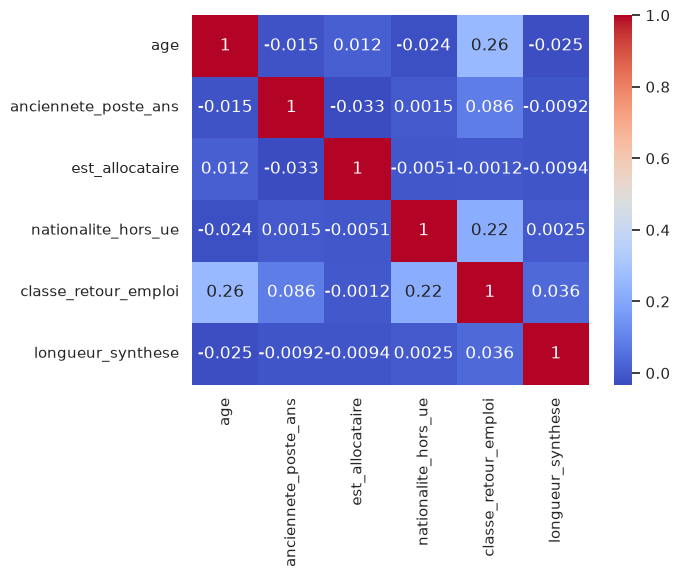

In [13]:
# Matrice de corrélation, pairplot, croisements clés vs cible

num_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

corr_matrix = df[num_cols].corr(numeric_only=True)

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

🔍 **Observation :**
> Les corrélations observées sont globalement faibles, ce qui suggère une faible redondance de l'information. Aucune variable ne présente à elle seule un fort pouvoir explicatif de la cible, ce qui laisse penser que la performance du modèle reposera principalement sur la combinaison des différentes sources d'information.
> 
> On note toutefois une corrélation relativement plus marquée entre l'`âge`, la variable sensible `nationalite_hors_ue` et la cible, éléments qui mériteront une attention particulière lors de la modélisation et de l'analyse des biais.

#### 3.5.2 Influence des variables numériques sur la cible 

##### Age et retour à l'emploi

L'âge est fréquemment cité comme un facteur influençant la réinsertion professionnelle. Les demandeurs les plus âgés présentent-ils davantage de risque de chômage longue durée ?

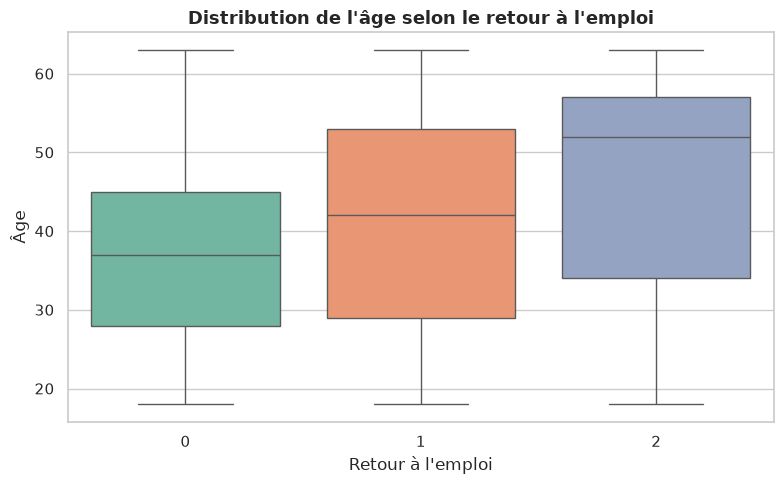

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="age",
    hue="classe_retour_emploi",
    palette="Set2",
    legend=False
)

plt.title(
    "Distribution de l'âge selon le retour à l'emploi",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Retour à l'emploi")
plt.ylabel("Âge")

plt.tight_layout()
plt.show()


🔍 **Observations :**
> Ce graphique met en évidence une relation positive entre l'âge et le délai de retour à l'emploi. La tendance globale est claire : plus l'âge augmente, plus le délai de retour à l'emploi semble s'allonger. Néanmoins, le chevauchement important des distributions indique que cette variable doit être combinée à d'autres facteurs pour prédire efficacement la cible.


##### Ancienneté dans le dernier poste et retour à l'emploi

L'ancienneté peut refléter l'expérience professionnelle accumulée. La stabilité professionnelle passée influence-t-elle le retour à l'emploi ?

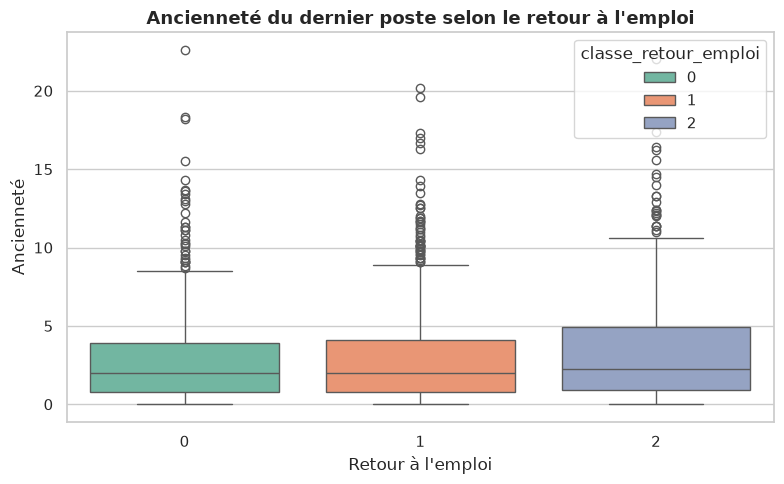

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="classe_retour_emploi",
    y="anciennete_poste_ans",
    hue="classe_retour_emploi",
    palette="Set2",
)

plt.title(
    "Ancienneté du dernier poste selon le retour à l'emploi",
    fontsize=13,
    weight="bold"
)

plt.xlabel("Retour à l'emploi")
plt.ylabel("Ancienneté")

plt.tight_layout()
plt.show()

🔍 **Observations :**
> Les distributions d'ancienneté sont relativement proches entre les trois classes et présentent un fort chevauchement. Bien que les bénéficiaires de la classe 2 semblent avoir une ancienneté légèrement plus élevée, cette variable ne paraît pas, à elle seule, suffisamment discriminante pour distinguer clairement les catégories de retour à l'emploi.

#### 3.5.3 Influence des variables catégorielles

##### Niveau de diplôme vs retour à l'emploi
Le niveau d'études constitue classiquement un facteur explicatif de l'insertion professionnelle. Le retour à l'emploi varie-t-il selon le niveau de diplôme ?

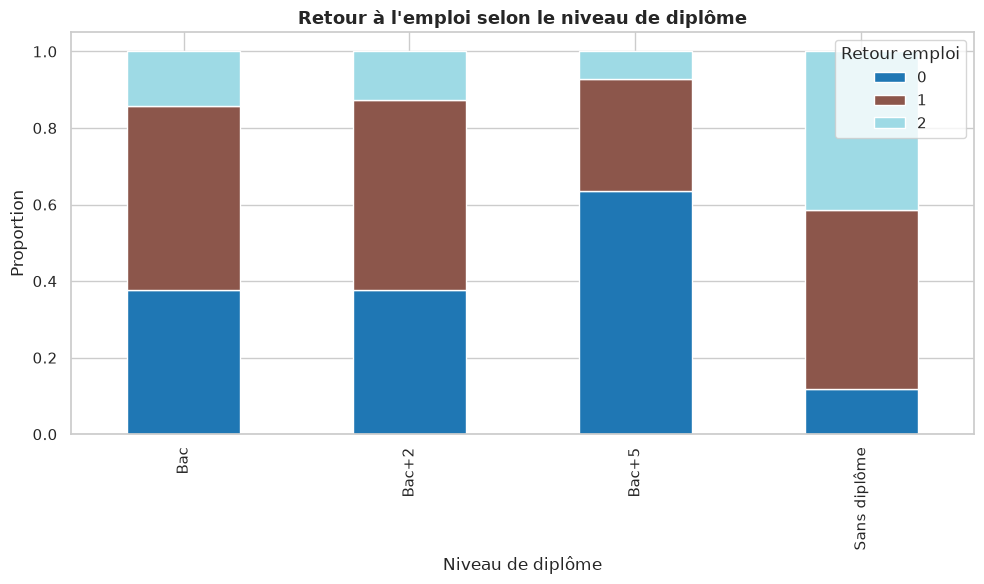

In [16]:
diplome_ct = pd.crosstab(
    df["niveau_diplome"],
    df["classe_retour_emploi"],
    normalize="index"
)

diplome_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab20"
)

plt.title(
    "Retour à l'emploi selon le niveau de diplôme",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Niveau de diplôme")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

🔍 **Observations :**
> Le niveau de diplôme apparaît comme une variable discriminante pour la cible. La proportion de retours rapides à l'emploi augmente avec le niveau de qualification, alors que les bénéficiaires sans diplôme présentent davantage de situations de retour à l'emploi tardif. Ce résultat est cohérent avec les mécanismes observés sur le marché du travail, où le niveau de qualification influence généralement les opportunités d'insertion professionnelle.

##### Allocataire vs retour à l'emploi
Le statut d'allocataire peut refléter des situations socio-économiques différentes. Le retour à l'emploi varie-t-il selon le statut allocataire ?

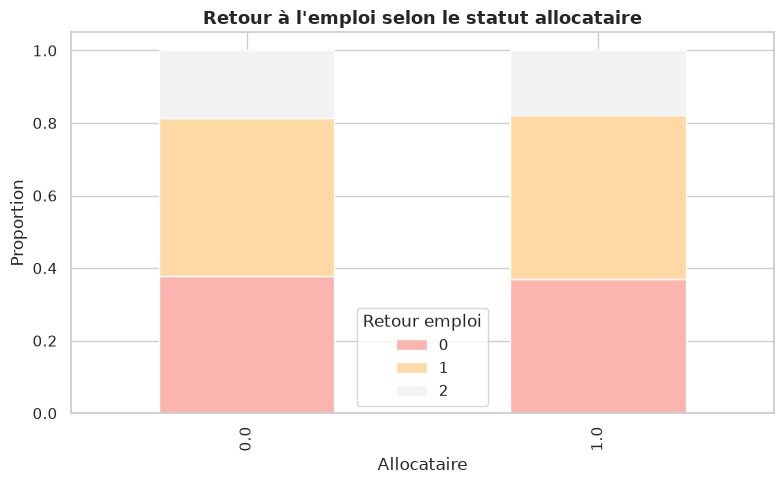

In [17]:
alloc_ct = pd.crosstab(
    df["est_allocataire"],
    df["classe_retour_emploi"],
    normalize="index"
)

alloc_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5),
    colormap="Pastel1"
)

plt.title(
    "Retour à l'emploi selon le statut allocataire",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Allocataire")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

**Observations :**
> L'histogramme ne montre pas d'impact du statut allocataire sur le retour à l'emploi

#### 3.5.6 Variable sensible : nationalité hors UE

Cette variable est considérée comme sensible et mérite une attention particulière afin de détecter d'éventuelles disparités. Existe-t-il une différence notable de répartition des classes selon la nationalité hors UE ?


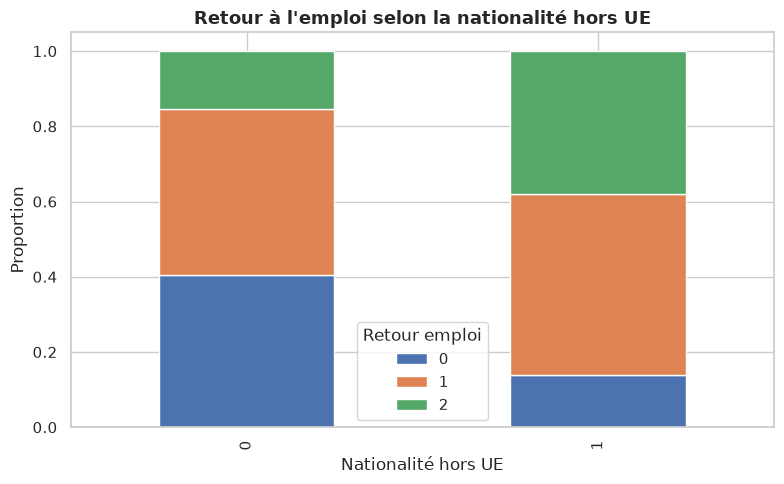

In [18]:
hors_ue_ct = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

hors_ue_ct.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title(
    "Retour à l'emploi selon la nationalité hors UE",
    fontsize=13,
    weight="bold"
)

plt.ylabel("Proportion")
plt.xlabel("Nationalité hors UE")

plt.legend(title="Retour emploi")

plt.tight_layout()
plt.show()

🔍 **Observations :**
> Une différence notable de répartition des classes est observée entre les deux groupes. Les personnes identifiées comme `nationalite_hors_ue = 1` présentent une proportion plus importante de retours à l'emploi tardifs (classe 2) et une proportion plus faible de retours rapides (classe 0). Cette variable semble donc associée à la cible, **mais son caractère sensible impose une analyse approfondie de son impact sur les performances et les risques de discrimination avant toute utilisation dans un modèle prédictif**.

#### 3.5.5 Observation finale


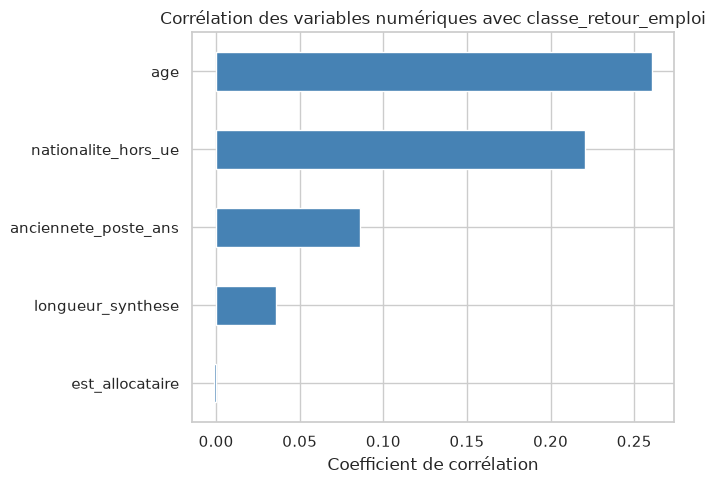

In [19]:
corr_target = (
    corr_matrix["classe_retour_emploi"]
    .drop("classe_retour_emploi")
    .sort_values()
)

plt.figure(figsize=(7, 5))

corr_target.plot(
    kind="barh",
    color="steelblue"
)

plt.title(
    f"Corrélation des variables numériques avec {"classe_retour_emploi"}"
)

plt.xlabel("Coefficient de corrélation")

plt.tight_layout()
plt.show()

En sytnhèse, l'analyse exploratoire met en évidence plusieurs variables susceptibles d'influencer le retour à l'emploi : notamment l'age, la nationalité et le niveau de diplôme. Ces résultats guideront la sélection des variables utilisées dans les modèles prédictifs tout en restant attentif aux risques de biais associés aux variables sensibles.

### 3.6 Analyse des biais et variables sensibles

L'analyse exploratoire a permis d'identifier plusieurs variables susceptibles d'introduire des biais dans les prédictions du modèle.

Parmi celles-ci, la variable `nationalite_hors_ue` mérite une attention particulière puisqu'elle constitue une caractéristique sensible au regard des enjeux de non-discrimination. Les analyses réalisées montrent une répartition différente des classes selon les groupes observés, ce qui suggère que cette variable contient une information potentiellement prédictive, mais son utilisation pourrait conduire le modèle à reproduire ou amplifier des biais présents dans les données historiques.

La variable `age` apparaît également liée au délai de retour à l'emploi, les bénéficiaires les plus âgés étant davantage représentés dans les classes correspondant aux retours à l'emploi les plus longs. Bien qu'informative d'un point de vue métier, cette caractéristique devra être utilisée avec vigilance afin d'éviter d'éventuels effets discriminatoires indirects.

Les différences observées lors de l'EDA ne permettent toutefois pas de conclure à l'existence d'un biais ou d'une discrimination algorithmique. Elles mettent uniquement en évidence des disparités présentes dans les données et justifient la réalisation d'analyses complémentaires lors de la phase de modélisation.

Une comparaison systématique des performances sera réalisée entre plusieurs scénarios, notamment avec et sans utilisation des variables sensibles. L'objectif sera d'évaluer le compromis entre performance prédictive, équité des résultats et conformité aux principes du RGPD et de l'IA responsable. 

### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

L'analyse exploratoire a permis de dégager plusieurs enseignements importants pour la suite du projet :

1. Le jeu de données présente une bonne qualité globale, avec un faible taux de valeurs manquantes (inférieur à 5 % pour toutes les variables concernées) et aucune donnée manquante sur la variable cible.
2. La variable cible est raisonablement équilibrée, même si la classe 2 (risque de chômage longue durée) reste minoritaire avec 18,08 % des observations. Ce déséquilibre demeure modéré et justifie une attention particulière lors de l'évaluation des modèles.
3. Les variables métier disponibles sont variées et complémentaires, combinant données numériques, catégorielles et textuelles. Cette richesse informationnelle laisse envisager un potentiel prédictif intéressant pour la modélisation multimodale.
4. Certaines variables présentent une relation observable avec la cible, notamment l'âge et le niveau de diplôme, tandis que les variables textuelles semblent contenir une information métier susceptible d'enrichir significativement les prédictions.
5. Des risques de biais ont été identifiés, en particulier autour de la variable `nationalite_hors_ue` et, dans une moindre mesure, de la variable age. Ces éléments justifient la mise en place d'analyses dédiées lors de la comparaison des différents scénarios de modélisation.

À l'issue de cette phase exploratoire, plusieurs hypothèses de travail sont retenues pour la suite du projet :

- les données sont suffisamment complètes pour privilégier une stratégie d'imputation plutôt qu'une suppression de lignes ;
- les variables textuelles devraient apporter une information complémentaire aux variables tabulaires ;
- les performances du modèle devront être évaluées au-delà de la seule accuracy, en particulier à travers le Recall de la classe 2 et le F1-score Macro ;
- des scénarios de comparaison avec suppression de variables sensibles sera nécessaire afin d'évaluer l'impact potentiel des biais.

Enfin, les objectifs définis lors du cadrage métier restent pertinents à ce stade de l'étude. Néanmoins, les cibles de performance seront réévaluées après les premiers entraînements afin de tenir compte des caractéristiques réelles observées dans les données et des performances effectivement atteignables.

Ces résultats confortent la pertinence des scénarios de modélisation prévus, notamment la comparaison entre données tabulaires seules, données multimodales et versions avec ou sans utilisation des variables sensibles.

Ci-dessous un récapitulatif des variables analysées :

In [20]:
summary_rows = []

for column in df.columns:

    missing_pct = round(df[column].isna().mean() * 100, 2)

    dtype = str(df[column].dtype)

    # Variables numériques
    if pd.api.types.is_numeric_dtype(df[column]):

        distribution = (
            f"Moy={df[column].mean():.2f} | "
            f"Min={df[column].min():.2f} | "
            f"Max={df[column].max():.2f}"
        )

    # Variables catégorielles / texte
    else:

        n_modalites = df[column].nunique(dropna=True)

        distribution = (
            f"{n_modalites} modalité(s)"
        )

    summary_rows.append(
        {
            "Variable": column,
            "Type": dtype,
            "Valeurs manquantes (%)": missing_pct,
            "Distribution": distribution
        }
    )

df_variables = pd.DataFrame(summary_rows)

df_variables

,Variable,Type,Valeurs manquantes (%),Distribution
0,usager_id,object,0.00,2500 modalité(s)
1,age,float64,4.88,Moy=40.57 | Min=18.00 | Max=63.00
2,niveau_diplome,object,3.36,4 modalité(s)
3,anciennete_poste_ans,float64,0.00,Moy=2.97 | Min=0.00 | Max=22.60
4,code_rome_vise,object,0.00,50 modalité(s)
5,code_insee_commune,object,0.00,2407 modalité(s)
6,est_allocataire,float64,1.76,Moy=0.60 | Min=0.00 | Max=1.00
7,nationalite_hors_ue,int64,0.00,Moy=0.12 | Min=0.00 | Max=1.00
8,synthese_entretien,object,3.24,9 modalité(s)
9,classe_retour_emploi,int64,0.00,Moy=0.81 | Min=0.00 | Max=2.00


---
## 4. Préparation des données

🎯 Construire un **pipeline de prétraitement reproductible** et comparable pour l'ensemble des scénarios d'entraînement.

💡 Cette section consiste à :
- sélectionner les variables retenues pour la modélisation ;
- définir les traitements adaptés à chaque type de données (numériques, catégorielles et textuelles) ;
- intégrer certaines considérations éthiques dans la préparation des données ;
- réaliser un découpage train/test stratifié afin de prévenir toute fuite de données ;
- encapsuler l'ensemble des transformations dans un pipeline unique réutilisable pour tous les modèles et scénarios.



### 4.1 Préparation des features

Cette phase consiste à définir les variables retenues pour la modélisation et à spécifier les traitements qui leur seront appliqués. Les choix effectués visent à garantir la qualité des données, la compatibilité avec les algorithmes d'apprentissage et la reproductibilité des expérimentations.

Avant le découpage train/test, seules les opérations de sélection et de définition des variables sont réalisées. Les calculs d'imputation, d'encodage et de normalisation seront effectués exclusivement sur les données d'entraînement au travers du pipeline.

#### 4.1.1 Sélection et traitement des variables 

| Variable | Type | Valeurs manquantes | Traitement dans le pipeline | Justification |
|-----------|------|-------------------|----------------------------|---------------|
| `usager_id` | Identifiant | Aucune | Suppression | Identifiant unique sans pouvoir prédictif, susceptible d'introduire du bruit dans l'apprentissage. |
| `age` | Numérique | 122 (4,9 %) | Imputation par la médiane → Standardisation (`StandardScaler`) | La médiane est robuste aux valeurs extrêmes. La standardisation harmonise les échelles des variables numériques. |
| `niveau_diplome` | Catégorielle | 84 (3,4 %) | Imputation par la modalité « Non renseigné » → Encodage One-Hot | L'absence d'information peut être porteuse de sens. Le One-Hot évite de créer un ordre artificiel entre les catégories. |
| `anciennete_poste_ans` | Numérique | Aucune | Standardisation (`StandardScaler`) | Mise à l'échelle des variables numériques pour améliorer la convergence et la comparabilité des coefficients. |
| `code_rome_vise` | Catégorielle | Aucune | Encodage One-Hot | Variable nominale sans ordre naturel. L'encodage binaire permet son exploitation par les algorithmes. |
| `code_insee_commune` → `departement` | Catégorielle | Aucune | Transformation en département → Encodage One-Hot | Réduction de la cardinalité, amélioration de la généralisation et limitation des biais liés à une géolocalisation trop fine. Cette agrégation s'inscrit également dans une démarche de minimisation des données. |
| `est_allocataire` | Binaire | 44 (1,8 %) | Imputation par le mode → Conservation au format 0/1 | Le faible nombre de valeurs manquantes justifie une imputation simple sans altérer la distribution de la variable. |
| `nationalite_hors_ue` | Binaire | Aucune | Conservation au format 0/1 | Variable directement exploitable. Retirée dans l'approche éthique afin de limiter les risques de discrimination indirecte. |
| `synthese_entretien` | Texte | 81 (3,2 %) | Remplacement par une chaîne vide → Vectorisation TF-IDF | TF-IDF permet de pondérer les termes en fonction de leur fréquence dans le corpus et de mettre en avant les éléments les plus discriminants pour la prédiction. |
| `classe_retour_emploi` | Variable cible | Aucune | Aucune transformation | Variable cible du problème de classification multiclasse. |

#### 4.1.2 Traitement du Code INSEE

La variable `code_insee_commune` est transformée en variable `departement`. Ce choix répond à un double objectif. 
- Premièrement, il réduit la cardinalité de la variable géographique et améliore la capacité de généralisation du modèle.
- Deuxièmement, il limite l'utilisation d'informations territoriales trop précises pouvant constituer des indicateurs indirects de situation sociale ou économique.

Cette agrégation géographique permet de conserver un contexte territorial pertinent pour l'analyse du retour à l'emploi tout en s'inscrivant dans une démarche d'IA responsable fondée sur les principes de minimisation des données, de proportionnalité et de réduction des biais algorithmiques.

In [21]:
# 4.1 Preparation des features

def extraire_departement(code_insee: str) -> str:
    """
    Extrait le code département à partir d'un code INSEE commune.

    Parameters
    ----------
    code_insee : str
        Code INSEE de la commune.

    Returns
    -------
    str
        Code département.
    """
    code_insee = str(code_insee)

    # Cas particuliers Corse
    if code_insee.startswith("2A"):
        return "2A"
    if code_insee.startswith("2B"):
        return "2B"
    # Départements métropolitains classiques
    return code_insee[:2]


# Création de la variable département
df["departement"] = df["code_insee_commune"].apply(extraire_departement)
# Vérification
print(df[["code_insee_commune", "departement"]].head())

# Nombre de départements représentés
print(
    f"Nombre de départements : "
    f"{df['departement'].nunique()}"
)

  code_insee_commune departement
0              18273          18
1              07240          07
2              01405          01
3              63359          63
4              21302          21
Nombre de départements : 96


In [22]:
# remplacer les valeurs nulles par une chaine vide pour traitement ultérieur
df["synthese_entretien"] = df["synthese_entretien"].fillna("")


#### 4.1.3 Initialisation des variables

In [23]:
# variables
# feat_num = ["age", "anciennete_poste_ans"]
# feat_cat = ["niveau_diplome", "code_rome_vise", "departement", "est_allocataire", "nationalite_hors_ue"]
# feat_txt = "synthese_entretien"
# target = "classe_retour_emploi"
# feat_sen = ["age", "nationalite_hors_ue"]

print(f"Features numériques  : {FEAT_NUM}")
print(f"Features catég.      : {FEAT_CAT}")
print(f"Features binaires    : {FEAT_BIN}")
print(f"Feature texte        : {FEAT_TXT}")
print(f"Target               : {TARGET}")


Features numériques  : ['age', 'anciennete_poste_ans']
Features catég.      : ['niveau_diplome', 'code_rome_vise', 'departement']
Features binaires    : ['est_allocataire', 'nationalite_hors_ue']
Feature texte        : synthese_entretien
Target               : classe_retour_emploi


### 4.2 Train/test split

Avant toute étape d'apprentissage, le jeu de données est séparé en ensembles d'entraînement et de test. Ce découpage permet d'évaluer les performances des modèles sur des données non observées lors de l'entraînement tout en prévenant les risques de fuite de données.

Le test est scellé jusqu'à l'étape [5]. `stratify=y` garantit que les 3 classes gardent leurs proportions dans les deux jeux — indispensable avec une classe à 18 %.

In [24]:
# 4.2 Train/test split (stratifié si classification déséquilibrée)

x = df[FEAT_NUM + FEAT_CAT + FEAT_BIN + [FEAT_TXT]]
y = df[TARGET]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=TEST_SIZE, stratify=y, random_state=SEED
)
print(x_train.shape, x_test.shape)
y_train.value_counts(normalize=True).round(3)

(2000, 8) (500, 8)


classe_retour_emploi
1    0.444
0    0.374
2    0.181
Name: proportion, dtype: float64

### 4.3 Instanciation du pipeline

Les opérations de prétraitement sont regroupées au sein d'un pipeline unique afin d'assurer l'application systématique et reproductible des transformations. Cette approche facilite également la comparaison des modèles dans un protocole expérimental homogène.

#### 4.3.1 Preprocessing



| Pipe | Colonnes | Traitement |
|---|---|---|
| `num` | âge, anciennete_poste_ans | imputation médiane + standardisation |
| `cat` | niveau_diplome, code_rome_vise, departement, est_allocataire, nationalite_hors_ue | imputation mode + OneHot (`handle_unknown=\"ignore\"`) |
| `txt` | synthese_entretien | TF-IDF (5 000 termes max) |


In [25]:
# 4.2 Pipeline de préprocessing : numériques + catégorielles + texte

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Non renseigné")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
bin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
])
txt_pipe = TfidfVectorizer(max_features=5000, min_df=3)

def build_preprocessor(num_features=None, cat_features=None, bin_features=None, txt_features=None):
    """
    Construit le préprocesseur adapté à un scénario donné.
    Chaque bloc (numérique, catégoriel, binaire, texte) est optionnel afin de permettre la comparaison de
    plusieurs scénarios de modélisation tout en
    conservant les mêmes traitements.
    """
    blocks = []
    if num_features:
        blocks.append(("num", num_pipe, num_features))
    if cat_features:
        blocks.append(("cat", cat_pipe, cat_features))
    if bin_features:
        blocks.append(("bin", bin_pipe, bin_features))    
    if txt_features:
        blocks.append(("txt", txt_pipe, txt_features))

    assert blocks, "Aucune colonne : verifie le perimetre du scenario"
    return ColumnTransformer(blocks)



**Reproductibilité :**

💡 Toutes les transformations sont encapsulées dans des objets scikit-learn afin de garantir la reproductibilité des expériences, la compatibilité avec la validation croisée stratifiée et la réutilisation du pipeline lors du déploiement.

### 4.4 Scénarios de jeux de données

Quatre scénarios sont définis afin d'évaluer l'influence des différentes catégories de données sur la qualité des prédictions. Cette démarche permet d'analyser l'apport respectif des variables structurées, des données textuelles et des variables sensibles dans le processus de modélisation.

| Scénario | Description | Variables conservées | Justification |
|---|---|---|---|
| S1 | Approche multimodale complète | Toutes | Scénario de référence (baseline). Toutes les informations disponibles sont exploitées afin d'obtenir le potentiel prédictif maximal et de mesurer l'apport combiné des données structurées et textuelles. |
| S2 | Approche Éthique | toutes sauf age et nationalité | Retrait des variables pouvant être considérées comme sensibles ou fortement corrélées à des critères protégés : age (donnée personnelle pouvant conduire à une discrimination liée à l'âge) et nationalite_hors_ue (critère directement lié à l'origine/nationalité). Cette approche s'inscrit dans les principes de minimisation des données, de non-discrimination et de protection des personnes promus par le RGPD et les recommandations de la CNIL. |
| S3 | Diagnostic par le texte seul  | synthese_entretien | Évaluation de la capacité du modèle à prédire le retour à l'emploi uniquement à partir du contenu sémantique des verbatims. Permet de mesurer la richesse informationnelle des synthèses d'entretien et la robustesse du modèle face au bruit textuel. | 
| S4 | Données contextuelles pures  | Synthèse exclue | Permet d'évaluer le pouvoir prédictif des seules données structurées sans apport du contexte sémantique. Ce scénario servira de point de comparaison pour quantifier la valeur ajoutée du traitement NLP. | 



In [26]:
# ==========================================================
# Préparation des scénarios
# ==========================================================

# Un scenario = un perimetre, decrit comme les arguments de build_preprocessor.
scenarios = {

    # S1 : Toutes les variables
    "S1": dict(
        num_features=project_cfg.FEATURES_NUMERIC,
        cat_features=project_cfg.FEATURES_CATEGORICAL,
        bin_features=project_cfg.FEATURES_BINARY,
        txt_features=project_cfg.FEATURE_TEXT,
    ),

    # S2 : Sans variables sensibles
    "S2": dict(
        num_features=[
            col
            for col in project_cfg.FEATURES_NUMERIC
            if col not in project_cfg.FEATURES_SENSITIVE
        ],
        cat_features=[
            col
            for col in project_cfg.FEATURES_CATEGORICAL
            if col not in project_cfg.FEATURES_SENSITIVE
        ],
        bin_features=[
            col
            for col in project_cfg.FEATURES_BINARY
            if col not in project_cfg.FEATURES_SENSITIVE
        ],
        txt_features=project_cfg.FEATURE_TEXT,
    ),

    # S3 : Texte uniquement
    "S3": dict(
        txt_features=project_cfg.FEATURE_TEXT,
    ),

    # S4 : Tabulaire uniquement
    "S4": dict(
        num_features=project_cfg.FEATURES_NUMERIC,
        cat_features=project_cfg.FEATURES_CATEGORICAL,
        bin_features=project_cfg.FEATURES_BINARY,
    ),
}

df_scenarios = (
    pd.DataFrame.from_dict(scenarios, orient="index")
      .rename_axis("scenario")
      .reset_index()
)

display(df_scenarios)


,scenario,num_features,cat_features,bin_features,txt_features
0,S1,"[age, anciennete_poste_ans]","[niveau_diplome, code_rome_vise, departement]","[est_allocataire, nationalite_hors_ue]",synthese_entretien
1,S2,[anciennete_poste_ans],"[niveau_diplome, code_rome_vise, departement]",[est_allocataire],synthese_entretien
2,S4,"[age, anciennete_poste_ans]","[niveau_diplome, code_rome_vise, departement]","[est_allocataire, nationalite_hors_ue]",NaN
3,S3,NaN,NaN,NaN,synthese_entretien


### 4.5 📝 Synthèse préparation

*[Choix de pipeline, scénarios construits, traçabilité.]*

Les données ont été préparées au sein d'un pipeline unique garantissant un traitement homogène pour l'ensemble des expérimentations. Les valeurs manquantes, les variables numériques/catégorielles/binaires, et les données textuelles sont prises en charge par des transformations adaptées à leur nature.

Quatre scénarios ont été définis afin de mesurer l'apport respectif des données tabulaires, textuelles et des variables sensibles. Cette démarche permettra de comparer les modèles dans un cadre méthodologique identique et d'analyser l'impact réel de chaque type d'information sur la prédiction du retour à l'emploi.

---
## 5. Modélisation & entraînement

🎯 **Comparer plusieurs modèles** avec validation croisée, choisir, justifier.

💡 Démarche scientifique : on pose une hypothèse, on teste, on compare. Pas un seul modèle « parce que je connais ».  
⚠️ Le scoring de validation croisée se fait **sur le train uniquement**. Le test set ne sert qu'à la fin.



| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|----------|----------|----------|----------|----------|----------|
| ML classique (scikit-learn, XGBoost, LightGBM, CatBoost) | Oui. Classification supervisée sur données tabulaires structurées avec un volume limité (~2 500 observations) et quelques variables textuelles pouvant être vectorisées (TF-IDF). | Faible | Élevée à moyenne selon le modèle | Aucune | **Retenue.** Famille la plus adaptée au problème, faible coût, bonne performance attendue, validation croisée facile, explicabilité compatible avec les contraintes métier et réglementaires. |
| Deep Learning (Keras, PyTorch) | Peu adapté. Généralement pertinent pour grands volumes de données, vision, audio ou NLP avancé. | Élevé (entraînement GPU souvent nécessaire) | Faible | Aucune | **Écartée.** Taille de dataset insuffisante pour justifier la complexité. Gain de performance improbable face à XGBoost/CatBoost sur données tabulaires. Ratio coût/bénéfice défavorable. |
| SLM local (Ollama, Mistral, Gemma, Phi, Llama ≤ 7B) | Partiellement adapté uniquement pour exploiter le texte libre sous forme générative. Pas optimisé pour prédire directement une cible de classification structurée. | Moyen | Faible à moyenne | Aucune | **Écartée.** Le besoin n'est pas de générer du texte mais de classer des dossiers. Une représentation TF-IDF intégrée dans un pipeline de ML classique est plus simple, plus explicable et moins coûteuse. |
| LLM API + RAG | Non. Le RAG répond à des questions sur une base documentaire et ne constitue pas un algorithme de classification supervisée adapté à ce problème. | Élevé (coût par appel et par token) | Faible | Forte (OpenAI, Anthropic, Mistral, etc.) | **Écartée.** Aucune base documentaire à interroger. Le problème consiste à prédire une classe à partir de variables d'entrée et non à rechercher de l'information. Surcoût sans bénéfice métier démontré. |
| Architecture agentique (multi-agents, outils externes, orchestrateurs) | Non. Pertinente pour l'exécution de tâches complexes multi-étapes ou l'automatisation de processus décisionnels. | Très élevé | Très faible | Forte | **Écartée.** Complexité disproportionnée par rapport au besoin. N'apporte aucune valeur directe pour une tâche de classification supervisée sur jeu de données statique. |

Après analyse des principales familles de solutions d'intelligence artificielle, le Machine Learning classique a été retenu comme approche principale. Le problème étudié est une tâche de classification supervisée sur un volume de données limité, composé majoritairement de variables tabulaires structurées et d'un champ textuel libre. Les approches de Deep Learning, SLM, LLM avec RAG et architectures agentiques ont été écartées car elles introduisent une complexité, un coût de calcul et une perte d'explicabilité qui ne sont pas justifiés par les caractéristiques du problème. Le benchmark comparatif sera donc réalisé sur plusieurs modèles de Machine Learning classique (régression logistique, Random Forest, XGBoost/CatBoost, etc.) évalués avec les mêmes folds de validation croisée et les mêmes métriques afin de sélectionner la solution la plus performante et la plus explicable.

### 5.1 Modèles candidats


**Modèles retenus**

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Régression Logistique | Linéaire | Baseline de référence, rapide, robuste, particulièrement adaptée aux variables TF-IDF et très interprétable | faible / faible | élevée |
| Random Forest | Ensemble (bagging) | Référence arbre robuste, peu sensible au bruit et au sur-apprentissage, nécessite peu de réglages | moyen / faible | moyenne |
| LightGBM | Ensemble (boosting) | Très performant et rapide sur données tabulaires, entraînement plus efficace que XGBoost sur certains jeux de données | moyen à élevé / faible | moyenne |
| XGBoost | Ensemble (boosting) | Référence industrielle pour les données tabulaires, excellente capacité à capturer les interactions complexes | élevé / faible | moyenne |


### 5.2 Entraînement & validation croisée

In [27]:
# 5.2 Entraînement & validation croisée
# Pour chaque modèle : Pipeline(preprocessor + estimator) + cross_val_score

models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),   
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    
    "LightGBM": LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        verbose=-1
    ),
    
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        device="cpu",
        tree_method="hist",
        n_jobs=-1
    ),
}

# validation croisée
cv = StratifiedKFold(n_splits=training_cfg.N_SPLITS,shuffle=True,random_state=training_cfg.SEED)

# Recall spécifique à la classe métier (classe 2)
recall_classe_2 = make_scorer(
    recall_score,
    labels=[2],
    average="macro",
    zero_division=0
)

scoring = {
    "f1_macro": "f1_macro",
    "recall_macro": "recall_macro",
    "recall_classe_2": recall_classe_2,
    "balanced_accuracy": "balanced_accuracy",
}


from src.benchmark import run_benchmark

df_benchmark = run_benchmark(
    models=models,
    scenarios=scenarios,
    x_train=x_train,
    y_train=y_train,
    cv=cv,
    scoring=scoring,
    build_preprocessor=build_preprocessor
)

display(df_benchmark)


/home/a453784/simplon-briefs/Atlas_CISIA_Exam/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/a453784/simplon-briefs/Atlas_CISIA_Exam/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/a453784/simplon-briefs/Atlas_CISIA_Exam/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

,f1_macro,écart-type,recall_macro,recall classe 2,bal. acc.,temps fit (s),temps inf. (s),scen,modele
0,0.672,0.014,0.689,0.685,0.689,0.143,0.0329,S1,LogisticRegression
1,0.678,0.017,0.687,0.644,0.687,1.537,0.2224,S1,RandomForest
2,0.699,0.022,0.703,0.652,0.703,18.079,0.0365,S1,LightGBM
3,0.699,0.020,0.690,0.566,0.690,1.466,0.0372,S1,XGBoost
4,0.645,0.014,0.660,0.636,0.660,0.073,0.0318,S2,LogisticRegression
5,0.640,0.018,0.653,0.627,0.653,1.502,0.1874,S2,RandomForest
6,0.631,0.024,0.640,0.591,0.640,21.802,0.0469,S2,LightGBM
7,0.625,0.020,0.621,0.475,0.621,0.823,0.0318,S2,XGBoost
8,0.635,0.017,0.654,0.661,0.654,0.042,0.0208,S3,LogisticRegression
9,0.635,0.017,0.654,0.661,0.654,1.312,0.1623,S3,RandomForest


### 5.3 Métriques retenues & justification

*[Classification : accuracy, F1 macro/micro/weighted, ROC-AUC, matrice de confusion. Régression : RMSE, MAE, R². Justifier le choix selon la cible et l'enjeu métier.]*

| Métrique | Conserver ? | Pourquoi ? |
|-----------|------------|-------------|
| Balanced Accuracy | ✅ Oui | Donne le même poids à chaque classe, indépendamment de leur fréquence. Plus pertinente que l'accuracy lorsque les classes sont déséquilibrées. Permet d'évaluer l'équilibre global du modèle. |
| Accuracy | ❌ Non | Peut être trompeuse en présence de classes déséquilibrées. Une bonne accuracy peut masquer de mauvaises performances sur la classe métier critique. |
| **F1-score macro** | ✅ **Oui (métrique principale)** | Compromis entre précision et rappel en donnant le même poids à chaque classe. Adaptée à un problème multiclasse avec déséquilibre et permet de comparer les modèles de manière équitable. |
| F1-score weighted | ❌ Non | Pondère les performances selon la fréquence des classes. Les classes majoritaires influencent davantage le score, ce qui peut masquer les difficultés sur la classe 2. |
| Recall macro | ✅ Oui | Mesure la capacité du modèle à retrouver correctement les observations de chaque classe. Complète le F1 Macro en mettant l'accent sur le taux de détection global plutôt que sur le compromis précision/rappel. |
| **Recall classe 2** | ✅ **Oui (métrique métier)** | Mesure la capacité du modèle à détecter les usagers à risque de chômage longue durée (classe 2). Les faux négatifs étant particulièrement coûteux métier, cette métrique est prioritaire pour la sélection du modèle. |
| Temps de prédiction | ✅ Oui | Permet d'évaluer la rapidité d'inférence du modèle. Critère important dans une perspective de mise en production et de passage à l'échelle. |
| Temps d'entraînement | ✅ Oui | Permet de comparer le coût de calcul des modèles. Utile pour arbitrer entre gain de performance et complexité opérationnelle. |
| Matrice de confusion | ✅ Oui | Indispensable pour comprendre quelles classes sont confondues et analyser les erreurs du modèle. Complète les métriques agrégées. |



### 5.4 Comparaison des modèles : tableau de scores CV

#### 5.4.1 Protocole de sélection du meilleur modèle

La sélection du meilleur repose sur une approche multicritère afin de ne pas privilégier uniquement la performance globale, mais également de tenir compte des enjeux métier et des contraintes opérationnelles du projet.

Trois dimensions sont considérées :

1. **Performance globale** : mesurée par le `F1-score macro`, retenu comme métrique principale. Cette métrique combine précision et rappel tout en accordant le même poids à chaque classe, indépendamment de leur fréquence. Elle est particulièrement adaptée aux problèmes de classification multiclasse présentant un léger déséquilibre.

2. **Performance métier** : mesurée par le `Recall de la classe 2`. Cette métrique évalue la capacité du modèle à identifier les usagers présentant un risque de chômage de longue durée. Les faux négatifs sur cette classe étant considérés comme les erreurs les plus coûteuses d'un point de vue métier, cette métrique constitue un critère déterminant dans le choix du modèle.

3. **Coût de calcul** : mesuré par le `temps moyen d'entraînement` et le `temps moyen de prédiction` observés lors de la validation croisée. Ces indicateurs permettent d'évaluer la sobriété de la solution, sa capacité à être réentraînée régulièrement et son aptitude à être déployée dans un contexte opérationnel.

Les métriques `Balanced Accuracy` et `Recall macro` sont utilisées comme indicateurs complémentaires afin de vérifier qu'une amélioration des performances sur la classe métier critique ne se fait pas au détriment des autres classes.

Lors de l'analyse des résultats, la priorité est donnée au compromis entre `F1-score macro` et `Recall de la classe 2`, les métriques de coût de calcul intervenant comme critères d'arbitrage lorsque plusieurs modèles présentent des performances comparables.

> **Note :** La stabilité du modèle est évaluée à partir de l'écart-type du `F1-score macro` observé lors de la validation croisée stratifiée à 5 plis. Un faible écart-type traduit une meilleure robustesse du modèle face aux variations des données d'entraînement et renforce la confiance dans sa capacité de généralisation.

#### 5.4.2 Résultats observés
Le scénario S1 (ensemble complet des variables numériques, catégorielles et textuelles) obtient les meilleures performances globales. Les scénarios S2, S3 et S4 présentent systématiquement des résultats inférieurs, ce qui indique que les différentes familles de variables apportent une information complémentaire utile à la prédiction.

🔬 **Analyse**

##### Étape 1 : classement selon le F1-score macro

Le classement des modèles selon le F1-score macro montre que les meilleures performances globales sont obtenues sur le scénario **S1**, qui combine l'ensemble des variables disponibles.

| Modèle | F1 Macro |
|----------|----------:|
| LightGBM | **0.700** |
| XGBoost | 0.695 |
| Logistic Regression | 0.673 |
| Random Forest | 0.673 |

Le modèle **LightGBM** obtient le meilleur F1-score macro (*0.700*), suivi de très près par **XGBoost** (*0.695*). L'écart entre ces deux modèles est limité à seulement **0,005 point**.


##### Étape 2 : analyse de la métrique métier

Le simple classement par F1-score macro ne suffit toutefois pas à répondre à l'objectif métier du projet. Une analyse complémentaire est donc réalisée à l'aide du **Recall de la classe 2**, qui mesure la capacité à détecter les situations de risque de chômage longue durée.

| Modèle (S1) | Recall Classe 2 |
|----------|----------:|
| Logistic Regression | **0.696** |
| LightGBM | 0.647 |
| Random Forest | 0.627 |
| XGBoost | 0.555 |

Cette analyse révèle des éléments importants :

- **Logistic Regression obtient le meilleur Recall Classe 2 du benchmark (0.696)** ;
- **XGBoost obtient le plus faible Recall Classe 2 du scénario S1 (0.555)** malgré son excellent F1-score macro ;
- La régression logistique arrive également en tête sur cette métrique dans les scénarios **S2** et **S4**, ce qui confirme sa robustesse lorsqu'il s'agit d'identifier les situations les plus critiques.

Compte tenu de ces résultats, les modèles **Random Forest** et **XGBoost** sont écartés de la sélection finale. Bien qu'ils présentent des performances correctes en F1-score macro, leur capacité à détecter les observations appartenant à la classe 2 apparaît insuffisante au regard de l'objectif métier.

##### Étape 3 : arbitrage entre LightGBM et Logistic Regression

Les deux candidats restants présentent des profils complémentaires :

| Critère | Logistic Regression (S1) | LightGBM (S1) |
|----------|----------:|----------:|
| F1 Macro | 0.673 | **0.700** |
| Recall Classe 2 | **0.696** | 0.647 |
| Balanced Accuracy | 0.691 | **0.703** |
| Écart-type | **0.011** | 0.022 |
| Temps d'entraînement | **0.079 s** | 10.503 s |
| Temps d'inférence | **0.0206 s** | 0.0285 s |

Le modèle **LightGBM** présente les meilleures performances globales avec un F1-score macro de **0.700**. Cependant, cet avantage reste limité à **0,027 point** par rapport à la régression logistique.

En revanche, la régression logistique :

- améliore le Recall Classe 2 de près de **5 points** (*0.696 contre 0.647*) ;
- présente une meilleure stabilité (*σ = 0.011 contre 0.022*) ;
- s'entraîne environ **130 fois plus vite** ;
- possède le meilleur temps d'inférence du benchmark ;
- offre une meilleure interprétabilité grâce à un modèle linéaire directement explicable.

Ainsi, le gain de performance globale apporté par LightGBM apparaît relativement faible au regard du surcoût computationnel observé et de la perte sur la métrique métier principale.

---

📌 **Décision finale**

**Le modèle retenu pour la phase d'optimisation est la régression logistique du scénario S1.**

##### Justification

- ✅ Meilleur Recall Classe 2 du benchmark (**0.696**) ;
- ✅ F1-score macro proche des meilleurs modèles (**0.673 contre 0.700 pour LightGBM**) ;
- ✅ Balanced Accuracy élevée (**0.691**) ;
- ✅ Meilleure stabilité observée (**σ = 0.011**) ;
- ✅ Coût d'entraînement et d'inférence les plus faible ;
- ✅ Excellente explicabilité du modèle ;
- ✅ Choix cohérent avec l'objectif métier consistant à limiter les erreurs critiques sur les situations de chômage longue durée.

La phase suivante consistera à optimiser ce modèle en ajustant les hyperparamètres, les poids de classes et le seuil de décision afin d'améliorer encore la détection de la classe 2 tout en conservant un bon niveau de performance globale.


### 5.5 Optimisation des hyperparamètres


🎯 Objectif : Faire 2 ou 3 expériences ciblées qui répondent à des hypothèses.
l'idée est de tester : 
- Une référence
- Une version régularisée
- Une version plus complexe

In [28]:
# =====================================================
# Configurations à comparer
# =====================================================

model_params = {
    "LR_baseline" : LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    ),
    # Regularisation forte
    "LR_C0.1": LogisticRegression(
        C=0.1,
        solver="saga",
        l1_ratio=0.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    ),
    # Regularisation faible
    "LR_C10": LogisticRegression(
        C=10,
        solver="saga",
        l1_ratio=0.0,
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    ),
    # ElasticNet
    "LR_ElasticNet": LogisticRegression(
        C=1,
        solver="saga",
        l1_ratio=0.5,
        max_iter=5000,
        class_weight="balanced",
        random_state=42,
    ),
}


# =====================================================
# Evaluation par validation croisée
# =====================================================

results_df = (
    run_benchmark(
        models=model_params,
        scenarios={"S1": scenarios["S1"]},
        x_train=x_train,
        y_train=y_train,
        cv=cv,
        scoring=scoring,
        build_preprocessor=build_preprocessor
    )
    .sort_values(
        by="f1_macro",
        ascending=False
    )
    .reset_index(drop=True)
)

display(results_df)


# =====================================================
# Meilleur modèle
# =====================================================

best_model_name = results_df.iloc[0]["modele"]

print("\n🏆 Meilleur modèle :", best_model_name)


,f1_macro,écart-type,recall_macro,recall classe 2,bal. acc.,temps fit (s),temps inf. (s),scen,modele
0,0.680,0.016,0.700,0.713,0.700,0.261,0.0237,S1,LR_C0.1
1,0.674,0.014,0.692,0.691,0.692,5.944,0.0227,S1,LR_ElasticNet
2,0.672,0.014,0.689,0.685,0.689,0.095,0.0287,S1,LR_baseline
3,0.642,0.026,0.657,0.633,0.657,0.285,0.0252,S1,LR_C10



🏆 Meilleur modèle : LR_C0.1


### 5.6 Évaluation finale sur le test set

On fige le choix (régression logistique), on ré-entraîne sur tout le train, on ouvre le test une seule fois.

ÉVALUATION FINALE - JEU DE TEST
Accuracy          : 0.706
Balanced Accuracy : 0.701
F1 Macro          : 0.687
Recall Classe 2   : 0.667

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0      0.759     0.759     0.759       187
           1      0.766     0.677     0.719       223
           2      0.517     0.667     0.583        90

    accuracy                          0.706       500
   macro avg      0.681     0.701     0.687       500
weighted avg      0.719     0.706     0.710       500



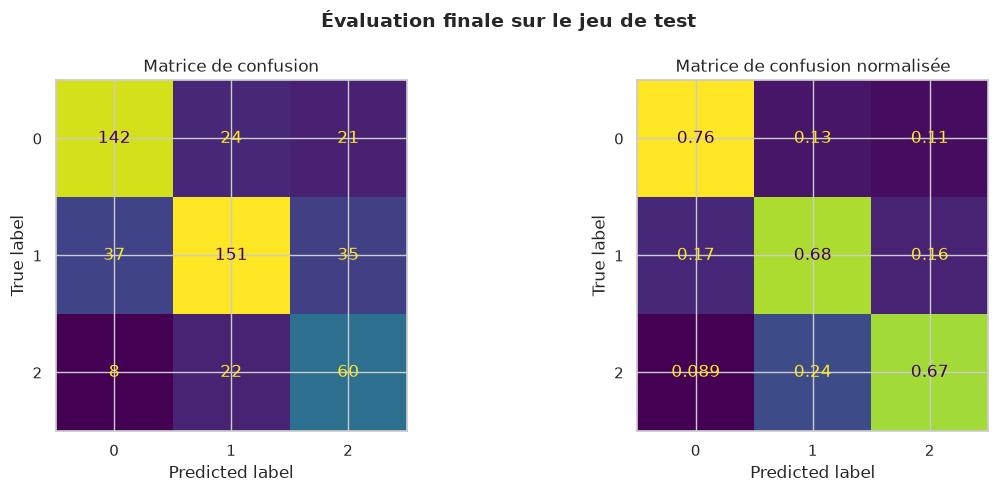

['../outputs/employment_risk_model.pkl']

In [29]:
from src.evaluation import evaluate_test_set

final_pipeline, y_pred, metrics = evaluate_test_set(
    model=model_params["LR_C0.1"],
    preprocessor=build_preprocessor(**scenarios["S1"]),
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test
)


# =====================================================
# Affichage métriques globales
# =====================================================

print("=" * 60)
print("ÉVALUATION FINALE - JEU DE TEST")
print("=" * 60)

print(f"Accuracy          : {metrics['accuracy']:.3f}")
print(f"Balanced Accuracy : {metrics['balanced_accuracy']:.3f}")
print(f"F1 Macro          : {metrics['f1_macro']:.3f}")
print(f"Recall Classe 2   : {metrics['recall_classe_2']:.3f}")

# =====================================================
# Rapport détaillé
# =====================================================

print("\nClassification Report")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        digits=3
    )
)

# =====================================================
# Matrices de confusion
# =====================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

# Matrice brute
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    ax=axes[0],
    colorbar=False
)

axes[0].set_title("Matrice de confusion")

# Matrice normalisée
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    ax=axes[1],
    colorbar=False
)

axes[1].set_title("Matrice de confusion normalisée")

plt.suptitle(
    "Évaluation finale sur le jeu de test",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =====================================================
# Sauvegarde locale du modèle
# =====================================================

joblib.dump(
    {
        "model": final_pipeline,
        "scenario": "S1",
        "features": scenarios["S1"]
    },
    "../outputs/employment_risk_model.pkl"
)

**Analyse des erreurs critiques :**

L'enjeu principal identifié lors du cadrage consiste à éviter qu'un demandeur d'emploi présentant un risque de chômage de longue durée (classe 2) soit classé dans une catégorie de risque plus faible et ne bénéficie pas de l'accompagnement adapté.

La matrice nous montre que sur les 90 observations appartenant à la classe 2 du jeu de test :
- 60 sont correctement classées en classe 2 ;
- 22 sont prédites en classe 1 ;
- 8 sont prédites en classe 0.

Le modèle atteint ainsi un recall de 66,7 % sur la classe métier prioritaire. L'erreur la plus critique (classe 2 → classe 0) reste relativement limitée et concerne 8,9 % des individus de la classe 2.

Les principales erreurs observées concernent les confusions entre les classes 1 et 2 :
- 24,4 % des individus de classe 2 sont prédits en classe 1 ;
- 15,7 % des individus de classe 1 sont prédits en classe 2.

Ces résultats confirment que le modèle privilégie raisonnablement la détection des situations les plus à risque. Les améliorations futures pourront principalement viser la réduction des confusions entre les classes 0-2 et 1-2 afin d'augmenter le rappel de la classe 2 sans dégrader les performances globales.

### 5.7 📝 Synthèse modélisation

- **Approche retenue**
  - Approche Machine Learning classique, adapté au faible volume de données et aux variables tabulaires et textuelles.
  - Évaluation réalisée par validation croisée stratifiée à 5 plis, appliquée exclusivement au jeu d'entraînement afin d'éviter toute fuite d'information.
  - Benchmark de quatre modèles : `Logistc Regression`, `Random Forest`, `LightGBM` et `XGBoost`.

- **Meilleur secnario** (hors considérations étiques)
  - **S1**, intégrant les variables numériques, catégorielles et textuelles.
  - Meilleures performances globales, résultat confirmant la complémentarité des différentes sources d'information et l'intérêt d'une approche multimodale pour la prédiction du retour à l'emploi.

- **Choix du modèle**
  - `LightGBM` obtient le meilleur F1 macro du benchmark : **0,700**.
  -  Malgré cet avantage, `Logistic regression` est retenue pour la phase d'optimisation car elle présente le meilleur compromis entre :
    + détection de la classe métier prioritaire (Recall Classe 2 = 0,696);
    +stabilité des performances (σ = 0,011) ;
    + rapidité d'entraînement et d'inférence ;
    + explicabilité du modèle.

- **Optimisation**
- Une optimisation ciblée de la régression logistique a été réalisée à l'aide de différentes stratégies de régularisation.
- La configuration retenue (`C = 0.1`, `class_weight="balanced"`) améliore l'ensemble des métriques observées en validation croisée par rapport au modèle de référence.

| Étape | Balanced Accuracy | F1 Macro | Recall Macro | Recall Classe 2 |
|---------|---------:|---------:|---------:|---------:|
| Régression Logistique (baseline S1) | 0,689 | 0,672 | 0,689 | 0,685 |
| Régression Logistique optimisée (`C=0.1`) | 0,700 | 0,680 | 0,700 | 0,713 |
| Évaluation finale sur le test | 0,701 | 0,687 | 0,701 | 0,667 |

- **Résultats sur le test scellé**
  - Les performances globales sont proches de celles obtenues en validation croisée,
  - Cette proximité entre validation croisée et test final indique une capacité de généralisation satisfaisante du modèle.

- **Points faibles**
   - La classe 2 demeure la plus difficile à prédire.
   - Le rappel de la classe 2 passe de **0,713** en validation croisée à **0,667** sur le jeu de test.
   - Malgré cette baisse, le modèle identifie encore correctement près de deux tiers des situations de chômage longue durée.
   - Les principales erreurs correspondent à des confusions entre les classes 1 et 2.

- **Conclusion**
  - La Régression Logistique régularisée constitue le meilleur compromis entre performance globale, détection des situations à risque, coût de calcul et explicabilité.
  - Les résultats obtenus valident la pertinence de l'approche retenue et répondent globalement aux objectifs définis lors du cadrage métier
  - Les principales pistes d'amélioration concernent :
      * l'analyse détaillée des erreurs ;
      * l'étude de l'impact des variables sensibles dans la section suivante ;
      * l'ajustement des seuils de décision afin d'améliorer encore la détection de la classe 2 sans réutiliser le jeu de test pour la sélection du modèle.

---
## 6. Analyse des scénarios & arbitrages

🎯 **Comparer les scénarios définis en 4.3** et argumenter le compromis performance / éthique / robustesse.

L'objectif de cette analyse est de comparer les quatre scénarios définis en section 4.4 afin d'évaluer l'impact des différentes catégories de données sur les performances du modèle, tout en prenant en compte les enjeux éthiques identifiés lors du cadrage

La comparaison est réalisée avec la régression logistique, afin de comparer les quatre périmètres de données avec un même algorithme et un protocole identique.


### 6.1 Tableau comparatif



| Scénario | Métrique principale (F1 Macro) | Métrique métier (R Classe 2) |  Métrique Secondaire (Bal. Acc) |Coût entraînement | Coût inférence | Explicabilité | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---:|---:|---:|---:|---:|---|---|---|
| **S1 – Multimodal complet** | **0,673 ± 0,011** | **0,696** | 0,691 | 0,105 s | 0,0244 s | **Élevée** : modèle linéaire, coefficients auditables | Risque élevé : conservation de l’âge et de `nationalite_hors_ue`. Mitigation nécessaire par l’analyse des écarts entre groupes, la documentation et la supervision humaine. | **Meilleure performance et meilleure détection de la classe 2. À retenir sous réserve d’un encadrement éthique renforcé.** |
| **S2 – Approche éthique** | 0,645 ± 0,012 | 0,636 | 0,660 | 0,061 s | 0,0210 s | **Élevée** : modèle linéaire, coefficients auditables | Risque réduit par le retrait de l’âge et de `nationalite_hors_ue`. Des biais indirects peuvent subsister dans le texte et les variables corrélées. | **Meilleur compromis éthique, avec une perte de performance modérée par rapport à S1.** |
| **S3 – Texte seul** | 0,635 ± 0,017 | 0,661 | 0,654 | 0,021 s | 0,0149 s | **Moyenne** : poids TF-IDF inspectables, mais interprétation répartie entre de nombreux termes | Absence de variable sensible explicite, mais risque de biais implicites et de variables proxys dans les synthèses d’entretien. | Le texte apporte une information prédictive réelle, mais reste insuffisant seul. |
| **S4 – Données structurées seules** | 0,544 ± 0,021 | 0,583 | 0,570 | 0,062 s | 0,0189 s | **Élevée** : variables et coefficients directement auditables | Risque élevé : conservation de l’âge et de `nationalite_hors_ue`, sans le gain prédictif du texte. | Scénario dominé : faible performance tout en conservant les principales variables sensibles. |

🔍 **Observation :**
> Les temps observés restent faibles pour les quatre scénarios. Par concéquent, le coût computationnel ne constitue pas un critère discriminant principal. L’arbitrage repose surtout sur la détection de la classe 2, la performance globale, la stabilité et les risques liés aux données utilisées.

### 6.2 Recommandation finale

Le **scénario S1** obtient les meilleures performances sur l'ensemble des métriques étudiées. Ces résultats confirment la complémentarité des données tabulaires et textuelles pour la prédiction du retour à l'emploi.

**Cout de l'équité**

Note :
> L'article 9 du RGPD interdit par principe le traitement des données révélant : *l'origine raciale ou ethnique, les opinions politiques, les convictions religieuses ou philosophiques, l'appartenance syndicale, [...], les données génétiques, la vie sexuelle ou l'orientation sexuelle*. La nationalité (UE/hors UE) n'apparait pas dans cette liste, mais reste très corrélée à une origine nationale et qui pourrait être utilisée comme substitut ("proxy") de l'origine ethnique ou de l'appartenance à un groupe protégé. Cette variable peut conduire à des différences de traitement entre catégories de population et doit donc être examinée avec prudence.

Le **scénario S2** permet de réduire l'exposition aux variables sensibles en supprimant l'âge et la variable nationalite_hors_ue. Cette suppression entraîne toutefois une baisse observable des performances :
- `F1 Macro : -0,028` ;
- `Recall Classe 2 : -0,060` ;
- `Balanced Accuracy : -0,0310`.

Les variables retirées apportent donc une information prédictive réelle, même si leur utilisation soulève des questions de conformité et de non-discrimination.

**Proposition**

D'un point de vue strictement prédictif, le **scénario S1** constitue le meilleur choix. Il maximise la détection des situations de chômage de longue durée, objectif métier prioritaire défini lors du cadrage. Une mauvaise classification d'un usager de `classe 2` vers la `classe 0` est considérée comme l'erreur la plus critique, car elle peut retarder l'accès à un accompagnement renforcé.

Toutefois, le **scénario S1** conserve des variables susceptibles d'introduire des biais de traitement. Le **scénario S2** représente ainsi une alternative crédible lorsque les exigences de conformité et de minimisation des données priment sur le gain de performance obtenu avec S1.

en conséquence :

- **S1** est retenu comme scénario de référence pour la performance métier ;
- **S2** constitue le scénario de repli le plus pertinent dans une logique de réduction des risques éthiques et réglementaires ;
- dans tous les cas, le système doit rester un outil d'aide à la décision, avec validation finale par le conseiller et suivi régulier des biais éventuels.

**Sources**

- [enjeux éthiques des algorithmes et de l'IA](https://www.cnil.fr/fr/comment-permettre-lhomme-de-garder-la-main-rapport-sur-les-enjeux-ethiques-des-algorithmes-et-de)
- [IA : comment être en conformité avec le RGPD ?](https://www.cnil.fr/fr/intelligence-artificielle/ia-comment-etre-en-conformite-avec-le-rgpd)
- [RGPD, article 9](https://www.cnil.fr/reglement-europeen-protection-donnees/chapitre2#Article9)


### 6.3 📝 Synthèse arbitrages

Le **scénario S1** fournit les meilleures performances globales et la meilleure capacité à détecter les situations de chômage longue durée. Le **scénario S2** réduit l'utilisation de variables sensibles au prix d'une baisse modérée des performances. Le choix final dépend donc du niveau de risque acceptable entre performance métier et exigences d'équité. Dans le cadre de cette étude, **S1** peut être retenu comme scénario de référence, sous réserve d'un encadrement reposant sur la transparence, l'audit des biais et la supervision humaine.

## 7. Industrialisation

🎯 Transformer le modèle en service exploitable : Tracking d'expériences, API, Interface utilisateur, déploiement

**Architecture :**

```mermaid
flowchart LR

USER["👤 Conseiller"]
ADMIN["👤 Admin"]

subgraph FRONT["🌐 Frontend"]
    direction TD
    ST["📊 Streamlit<br/><small>Interface Utilisateur</small>"]
    DB[("Database<br/><small>Historique requêtes</small>")]
    ST --> DB
end

subgraph API["⚡ API FastAPI"]
    P["/predict"]
    R["/retrain"]
end

subgraph MLOPS["🧠 MLOps"]
    MLF["📦 MLflow<br/><small>Model RegistryTracking</small>"]
    MOD["🤖 Production<br/><small>Modèle champion</small>"]
end

subgraph MON["📈 Monitoring"]
    PRO["📡 Prometheus"]
    GRA["📊 Grafana"]
end

USER --> ST
ST -- Rest API --> P

USER -- feedback --> DB

P -- chargement<br/>modèle --> MLF
MLF <--> MOD

P -- métriques --> PRO
PRO --> GRA

DB --> R
ADMIN --> R
R -- promeut --> MOD
```


Points clés de l'architecture :

- 🌐 **Interface utilisateur : Streamlit**

   Fournit une application web simple et interactive permettant aux utilisateurs de saisir les données d'entrée, lancer des prédictions et consulter les résultats.
  
- ⚡ **API REST : FastAPI (/predict, /retrain)**

   Constitue la couche de service de l'application. L'endpoint /predict réalise les inférences en temps réel, tandis que /retrain permet de déclencher le réentraînement du modèle lorsque de nouvelles données sont disponibles.

  
- 📦 **Gestion du cycle de vie des modèles : MLflow**

   Assure traçabilité et suivi des expérimentations, l'enregistrement des métriques d'entraînement, le versionnement des modèles et leur promotion vers les environnements de test ou de production. 

- 🤖 **Modèle de prédiction**

   Représente la version validée du modèle de Machine Learning utilisée en production pour réaliser les prédictions sur les nouvelles données.
  
- 📈 **Supervision et observabilité : Prometheus & Grafana**

   Prometheus collecte les métriques techniques de l'application (temps de réponse, erreurs, disponibilité), tandis que Grafana les restitue sous forme de tableaux de bord facilitant le suivi opérationnel et la détection d'anomalies.


- 🐳 **Déploiement et orchestration : Docker Compose**

   Permet d'exécuter l'ensemble des composants (Streamlit, FastAPI, MLflow, Prometheus et Grafana) dans des conteneurs isolés tout en simplifiant le déploiement, la maintenance et la reproductibilité de l'environnement.


- 🔄 **Réentraînement et amélioration continue des modèles**

   Les indicateurs collectés via le monitoring peuvent déclencher une analyse des performances et conduire à un nouveau cycle d'entraînement afin de maintenir la qualité du modèle dans le temps. Cette approche s'inscrit dans une démarche MLOps de supervision et d'amélioration continue.


### 7.1 Persistance et traçabilité du modèle

Afin de garantir la reproductibilité et la traçabilité du cycle de vie du modèle, les modèles entraînés sont gérés via MLflow. Chaque entraînement génère une expérience associée à un identifiant unique (Run ID) contenant les hyperparamètres, métriques, artefacts et versions du pipeline. Le modèle promu en production est enregistré dans le registre MLflow et l'API charge explicitement cette version plutôt qu'un fichier local non référencé.

#### 7.1.1 Configuration MLflow

In [30]:
# 7.1.1 Configuration MLflow

# =====================================================
# Configuration MLflow
# =====================================================

TRACKING_URI = system_cfg.MLFLOW_TRACKING_URI
EXPERIMENT_NAME = system_cfg.MLFLOW_EXPERIMENT_NAME
MODEL_NAME = system_cfg.MODEL_NAME

MLFLOW_AVAILABLE = False

# =====================================================
# test si le serveur MLflow est disponible
# =====================================================
try:
    mlflow.set_tracking_uri(TRACKING_URI)

    response = requests.get(f"{TRACKING_URI}/health", timeout=5)
    
    if response.status_code == 200:

        MLFLOW_AVAILABLE = True

        client = MlflowClient(tracking_uri=TRACKING_URI)
        mlflow.set_experiment(EXPERIMENT_NAME)
        experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

        print("Tracking URI :", mlflow.get_tracking_uri())
        print("✅ Serveur MLflow disponible")
        print(f"🧪 Expérience : {experiment.name}")

    else:

        print(
            f"⚠️ MLflow répond avec le code "
            f"{response.status_code}"
        )

except Exception as exc:

    print("⚠️ MLflow indisponible")
    print(exc)

    print(
        f"Les modèles seront sauvegardés localement "
        f"dans : {system_cfg.MODEL_PATH}"
    )

Tracking URI : http://localhost:5000
✅ Serveur MLflow disponible
🧪 Expérience : Employment_Prediction


#### 7.1.2 Entrainement et persistance MLflow

In [31]:
# 7.1.2 Entrainement et persistance MLflow
# par défaut, le modèle nouvellement entrainé est candidat

importlib.reload(TM)

if MLFLOW_AVAILABLE:
    best_pipeline = TM.train_model(
        model=model_params["LR_C0.1"],
        preprocessor=build_preprocessor(**scenarios["S1"]),
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        model_name=MODEL_NAME,
        alias="candidate"
    )
else:
    print("❌ MLflow indisponible")


🔄 Entraînement: employment_risk_model


2026/10/04 20:46:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'employment_risk_model' already exists. Creating a new version of this model...
2026/10/04 20:46:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: employment_risk_model, version 11


✅ Modèle employment_risk_model entraîné et logué avec succès dans MLflow.
   - Balanced-accuracy: 0.7011
   - Recall-macro: 0.7011
   - F1-Macro: 0.6870
   - Recall-classe-2: 0.6667


Created version '11' of model 'employment_risk_model'.


⭐ Run ID : 165737c374894340b7a9deae2f01eb11
   - Model version : 11
   - Alias : candidate
🏃 View run S1_employment_risk_model at: http://localhost:5000/#/experiments/1/runs/165737c374894340b7a9deae2f01eb11
🧪 View experiment at: http://localhost:5000/#/experiments/1


Interface MLflow :

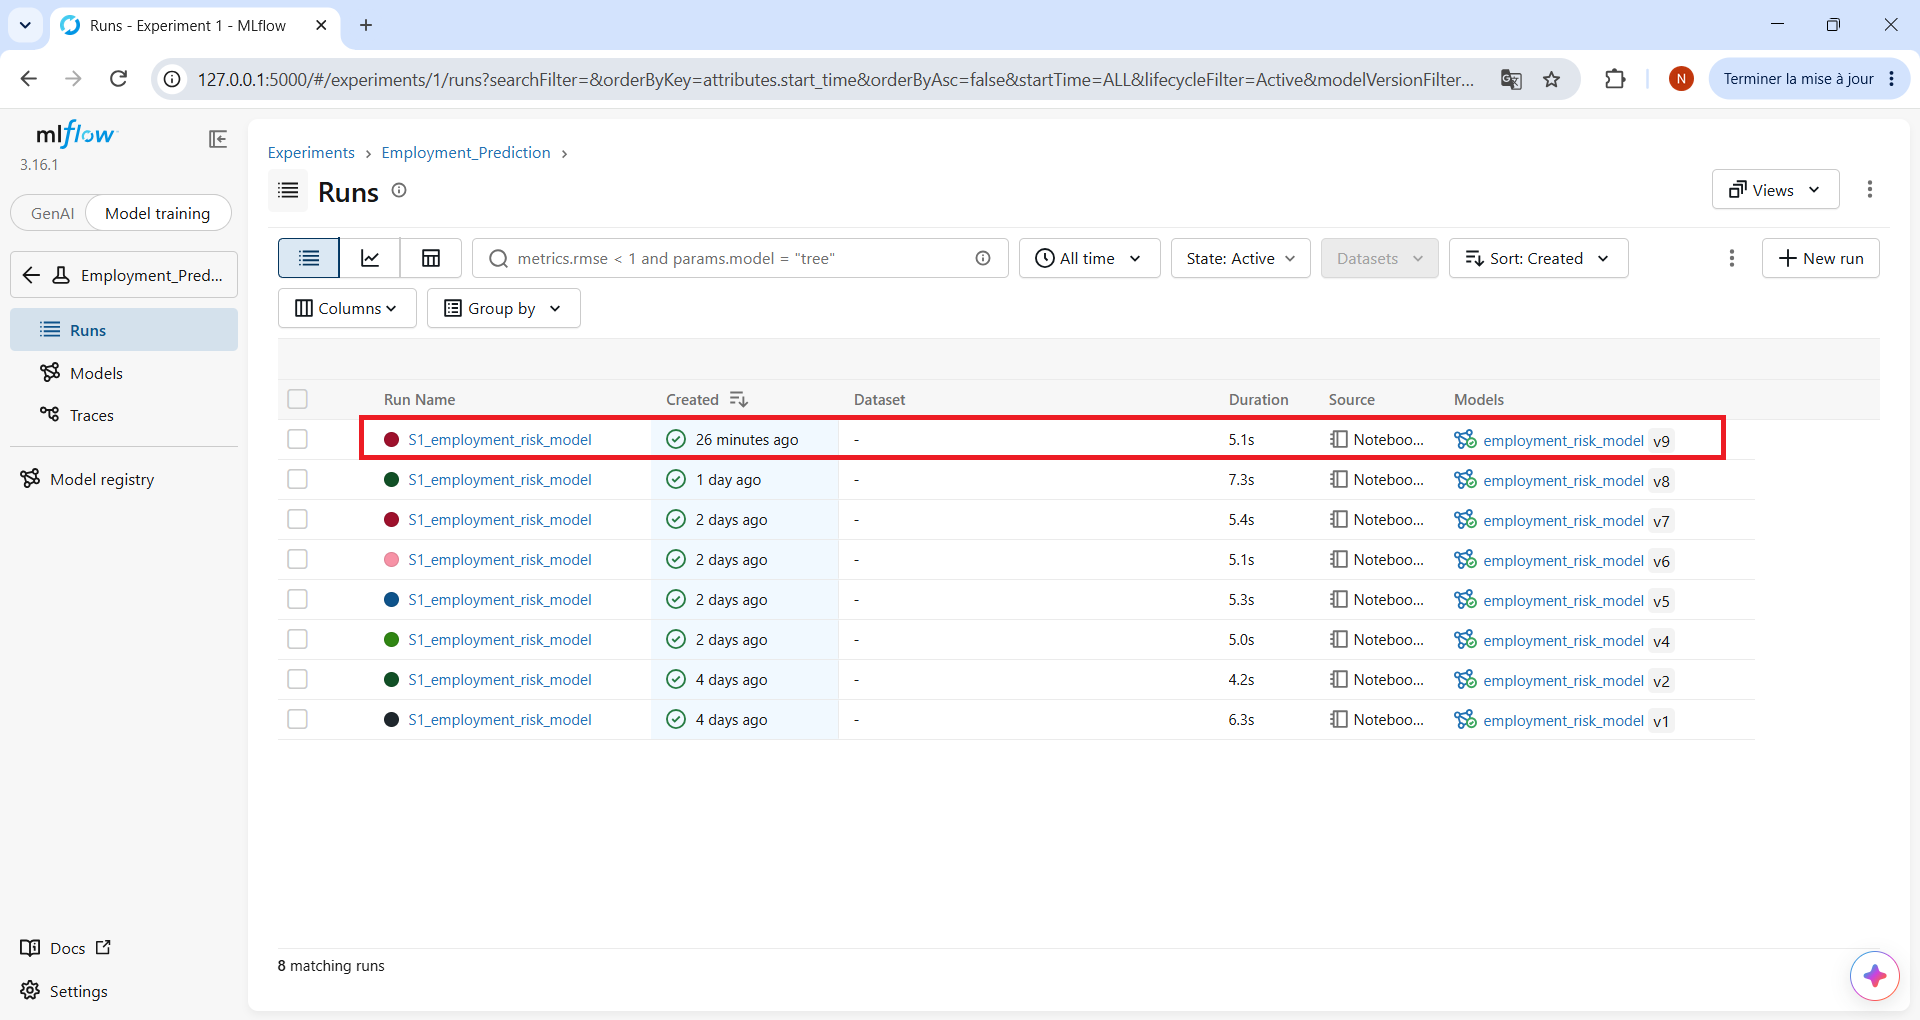


In [32]:
# 7.1.3 Promotion du modèle champion
# test de promotion du modèle champio dans MLflow : dans tous les cas on promeut

TM.promote_version_to_champion(
model_name="employment_risk_model"
)

✅ Version 11 promue CHAMPION


11

Promotion du modèle candidat :

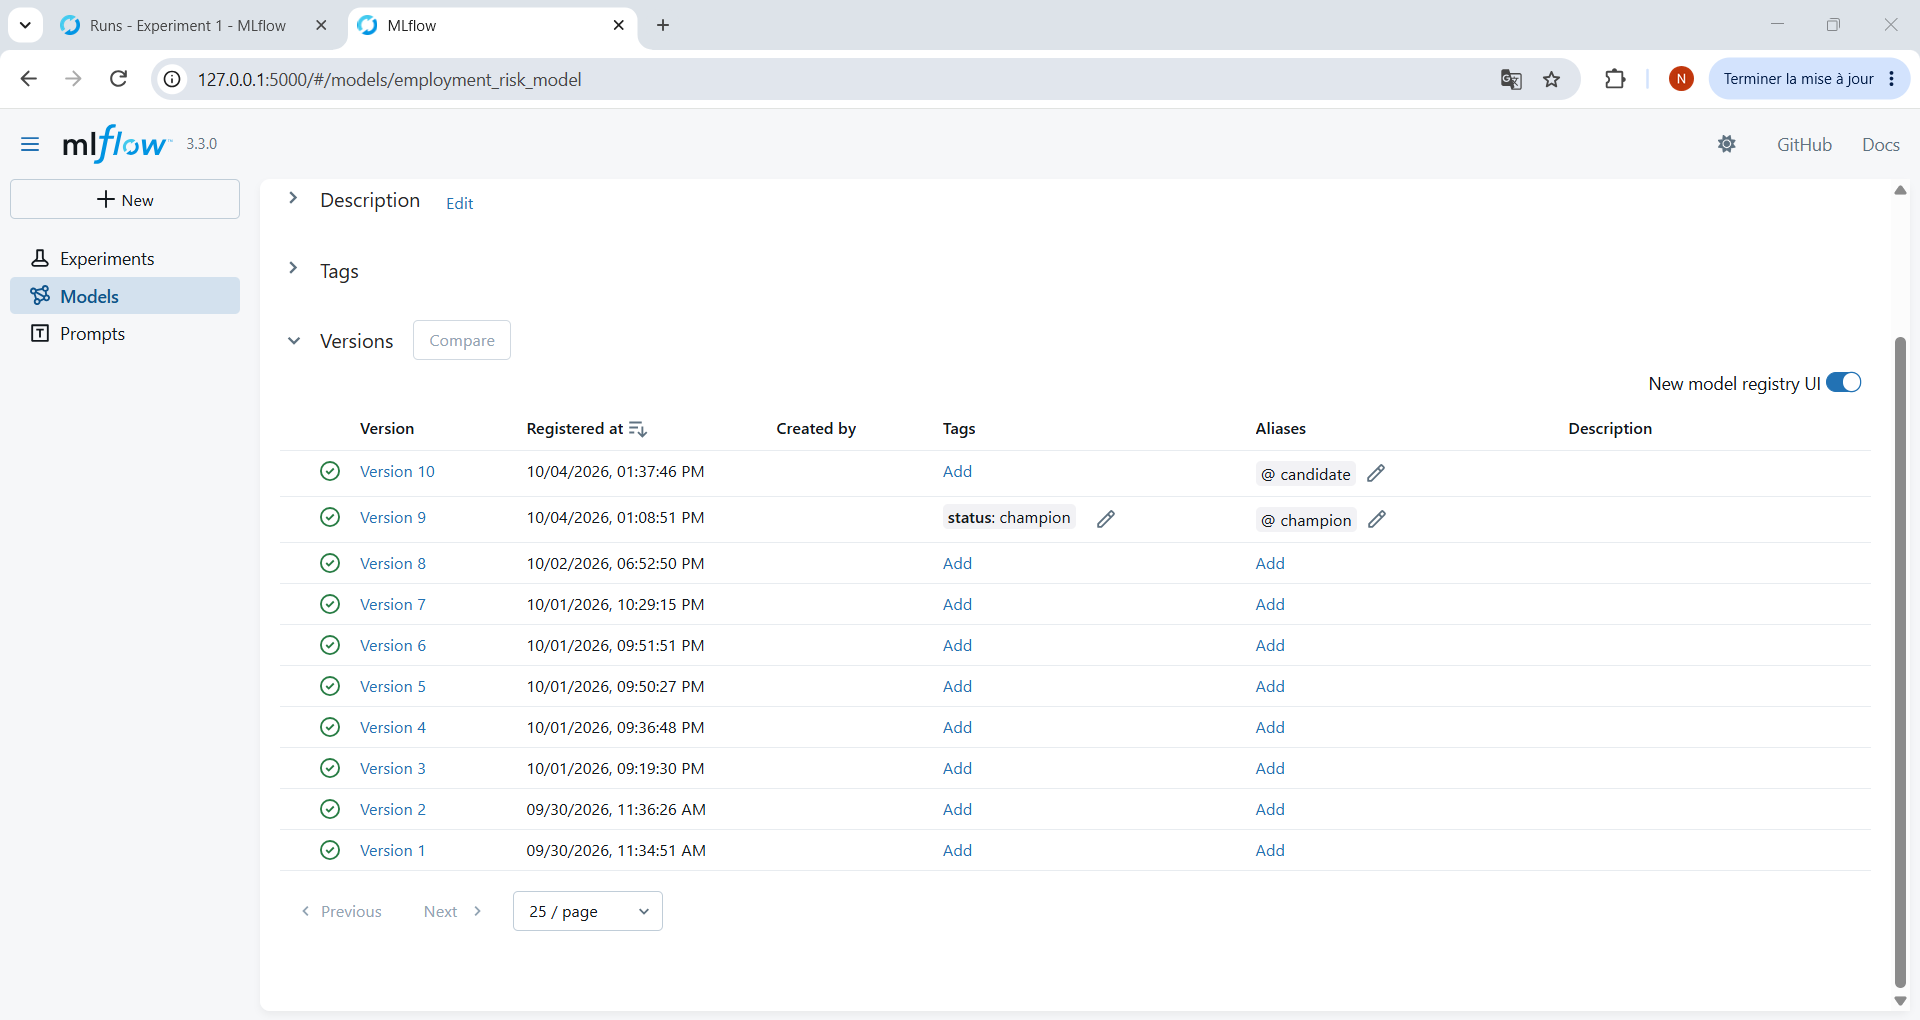

### 7.2 API de service

**Repo associé :**  https://github.com/NicoH77/Atlas_CISIA_Exam_EmploymentPrediction.git
   
   - 📁 : app

``` cmd
.
├── api
│   ├── logs
│   │   └── predictions.jsonl
│   ├── models
│   │   └── employment_risk_model.pkl
│   ├── Dockerfile
│   ├── main.py
│   └── requirements.txt
├── mlflow
│   ├── artifacts
│   └── mlflow-data
│       └── mlflow.db
├── ui
│   ├── database
│   │   └── history.db
│   ├── Dockerfile
│   ├── app.py
│   └── requirements.txt
└── docker-compose.yml
```

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | santé du service | — |
| `/model-info` | GET | Informations sur le modèle | — |
| `/predict` | POST | prédiction unitaire | Pydantic |
| `/train` | POST | (option) déclenche un réentraînement | Pydantic + auth |


#### 7.2.1 Fonctionalités

Les entrées API sont validées par Pydantic.

Les prédictions sont journalisées.




#### 7.2.3 Swagger

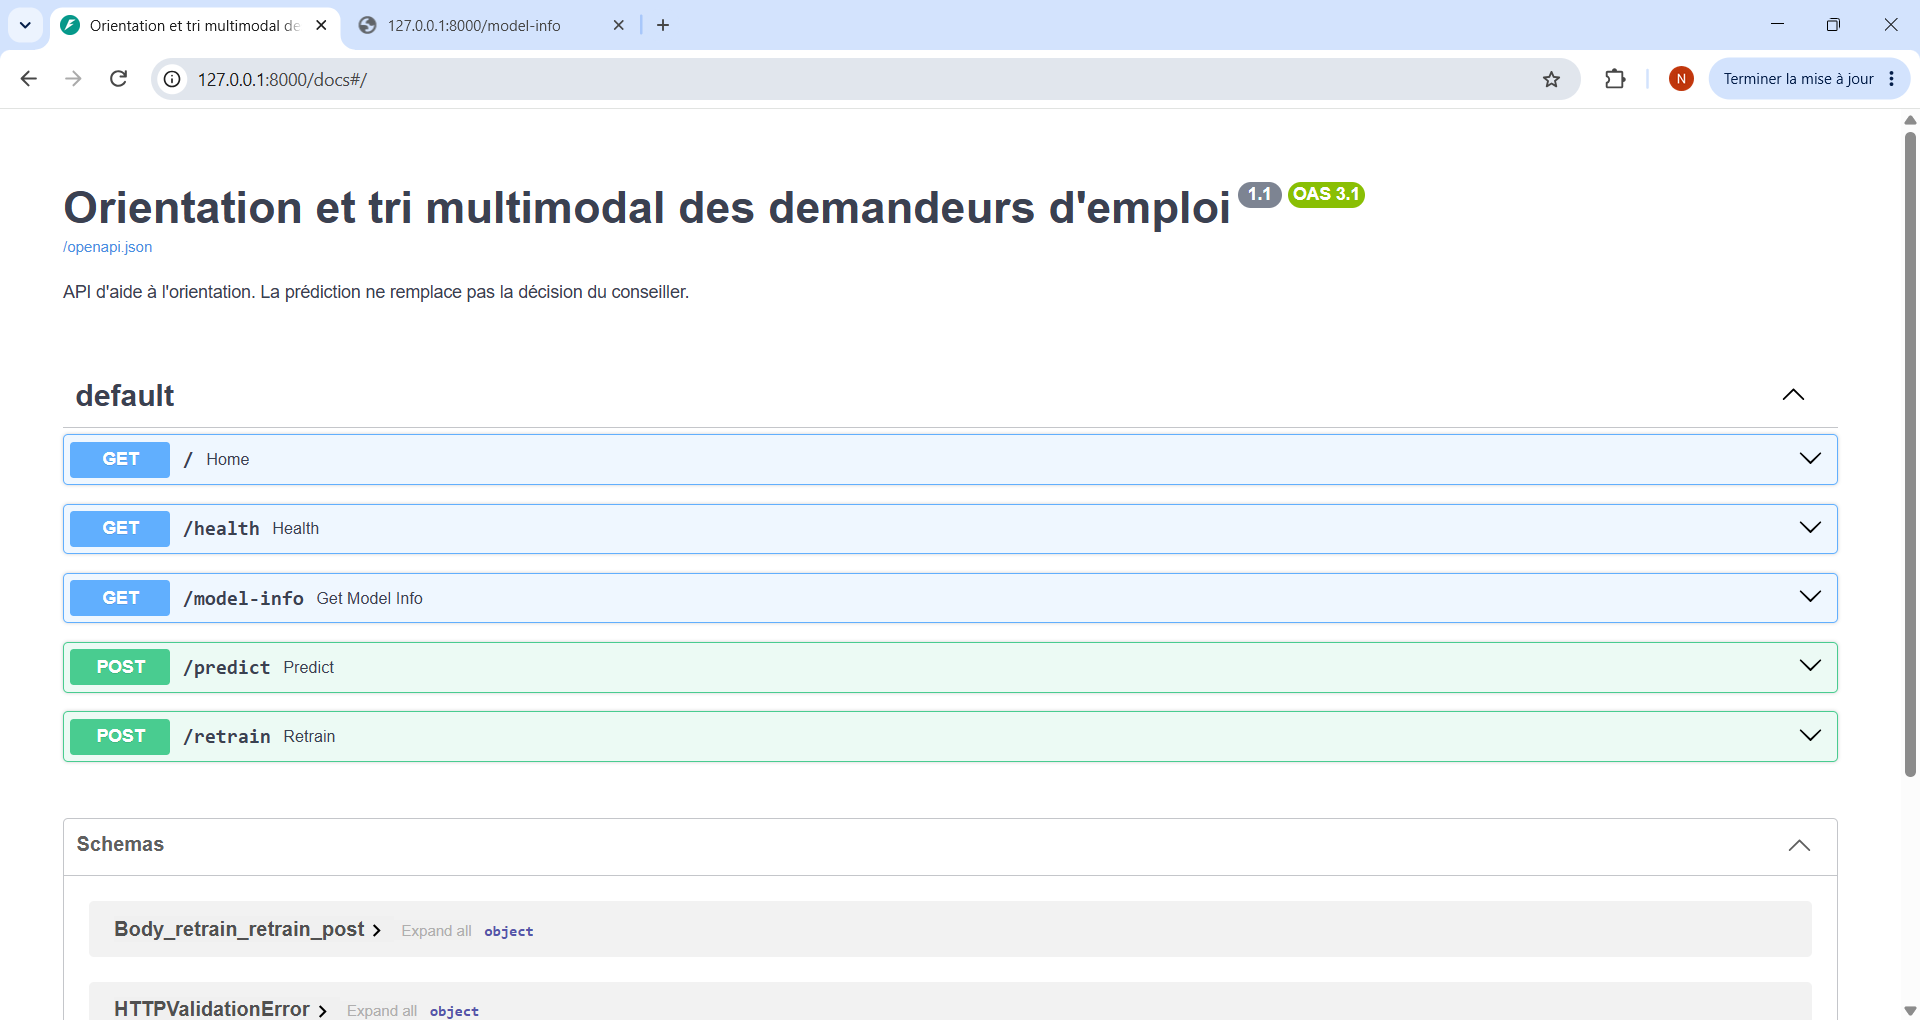




### 7.3 Health

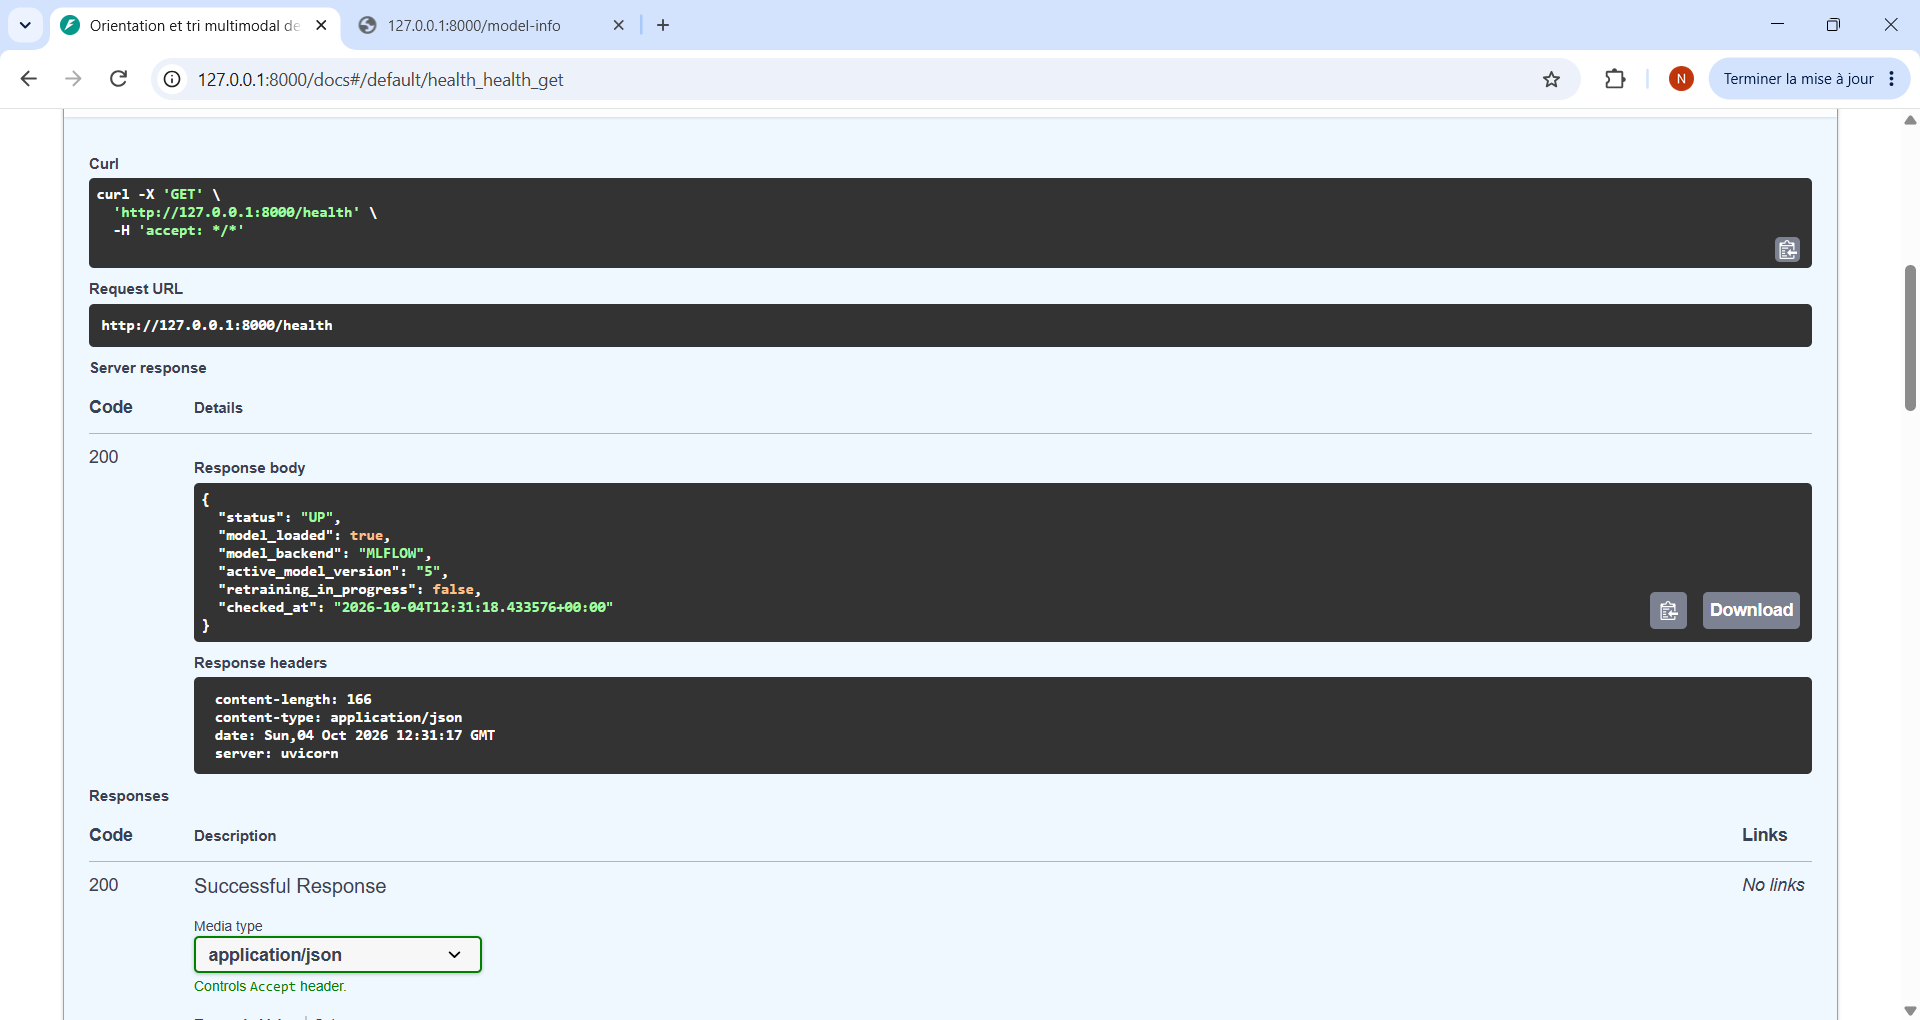

### 7.4 Predict

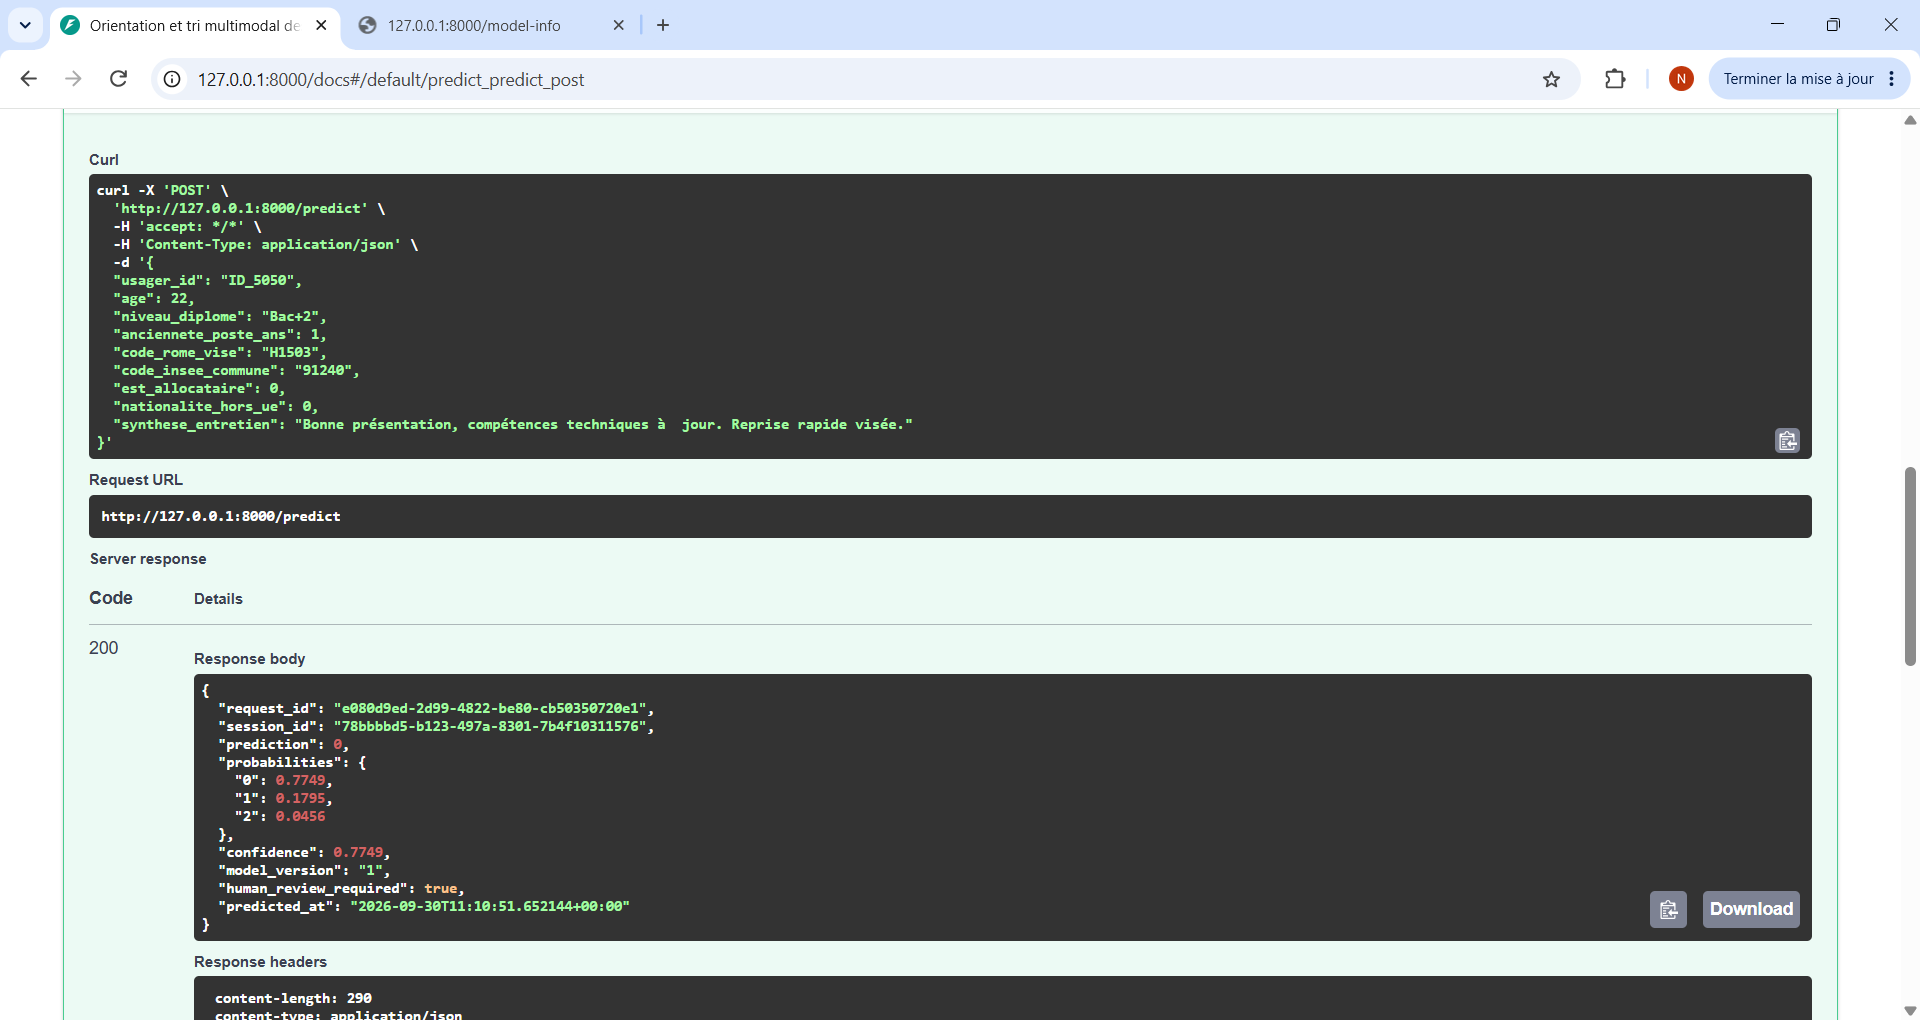




### 7.5 Interface utilisateur

Formulaire de prédiction :
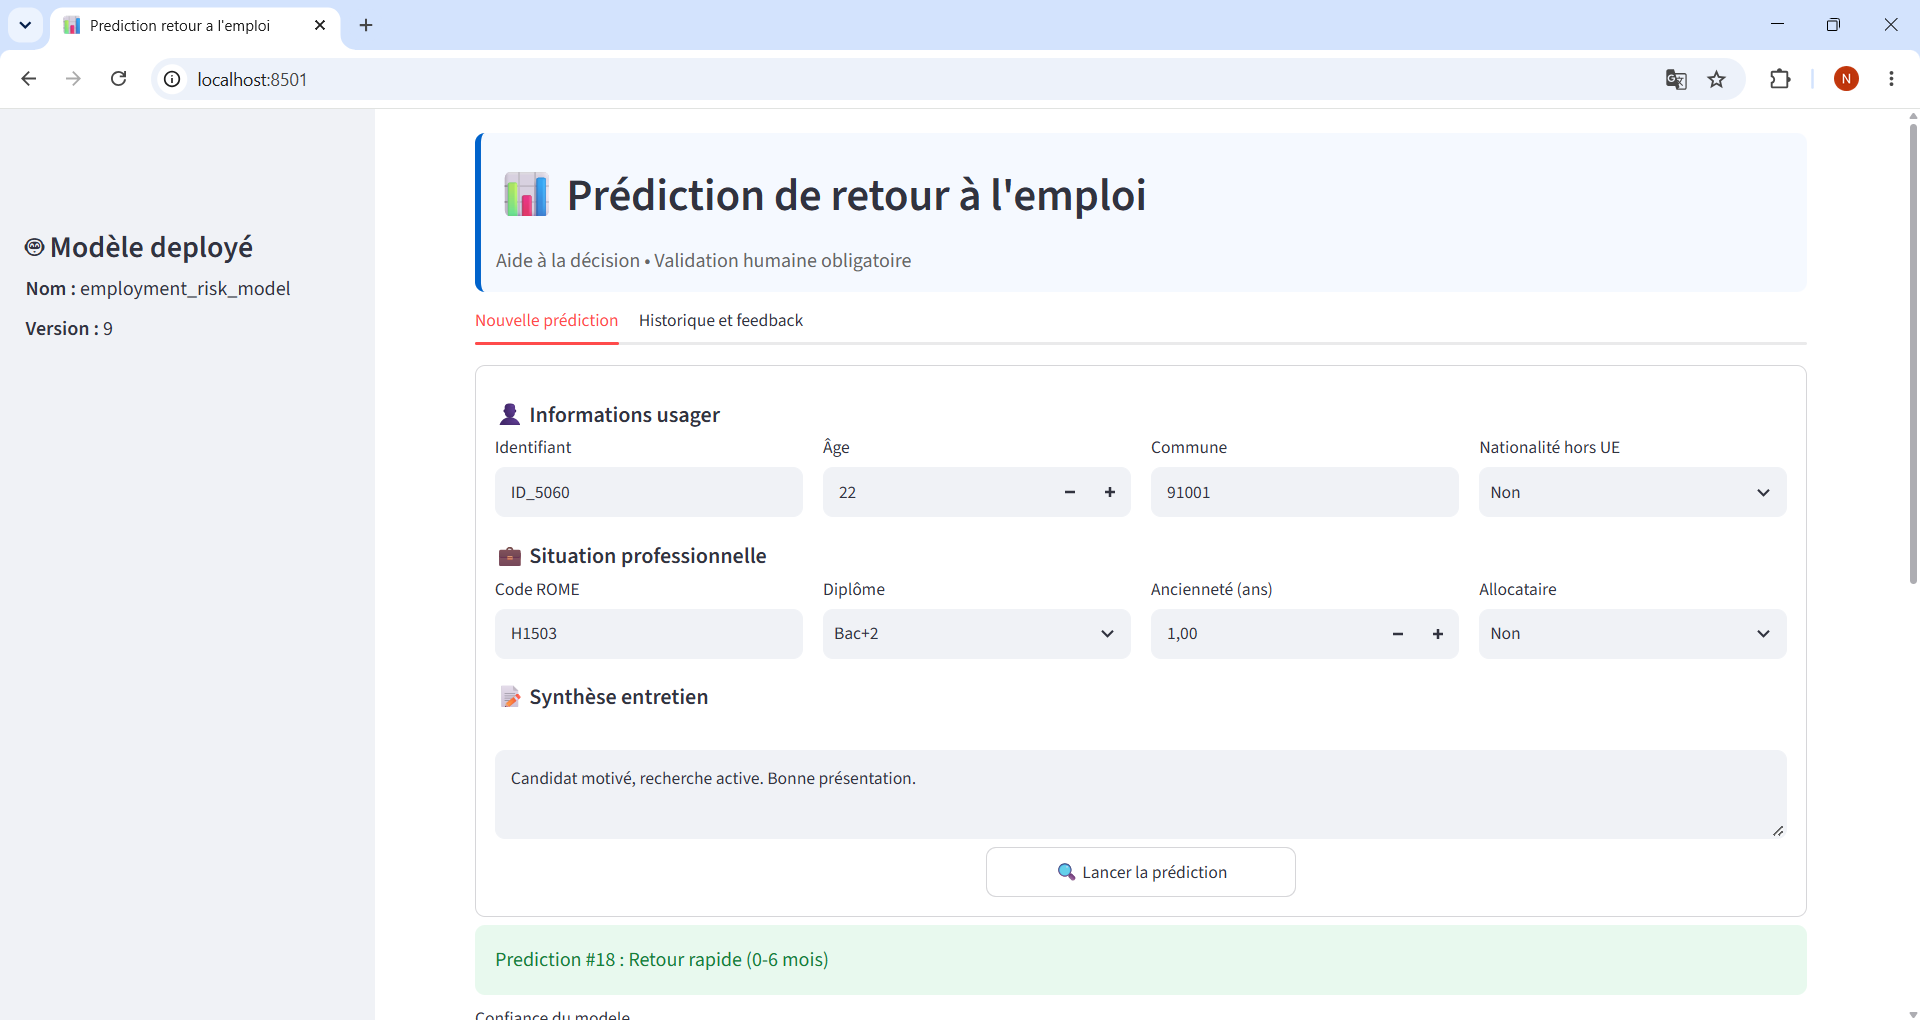

Résultat de la prédiction :
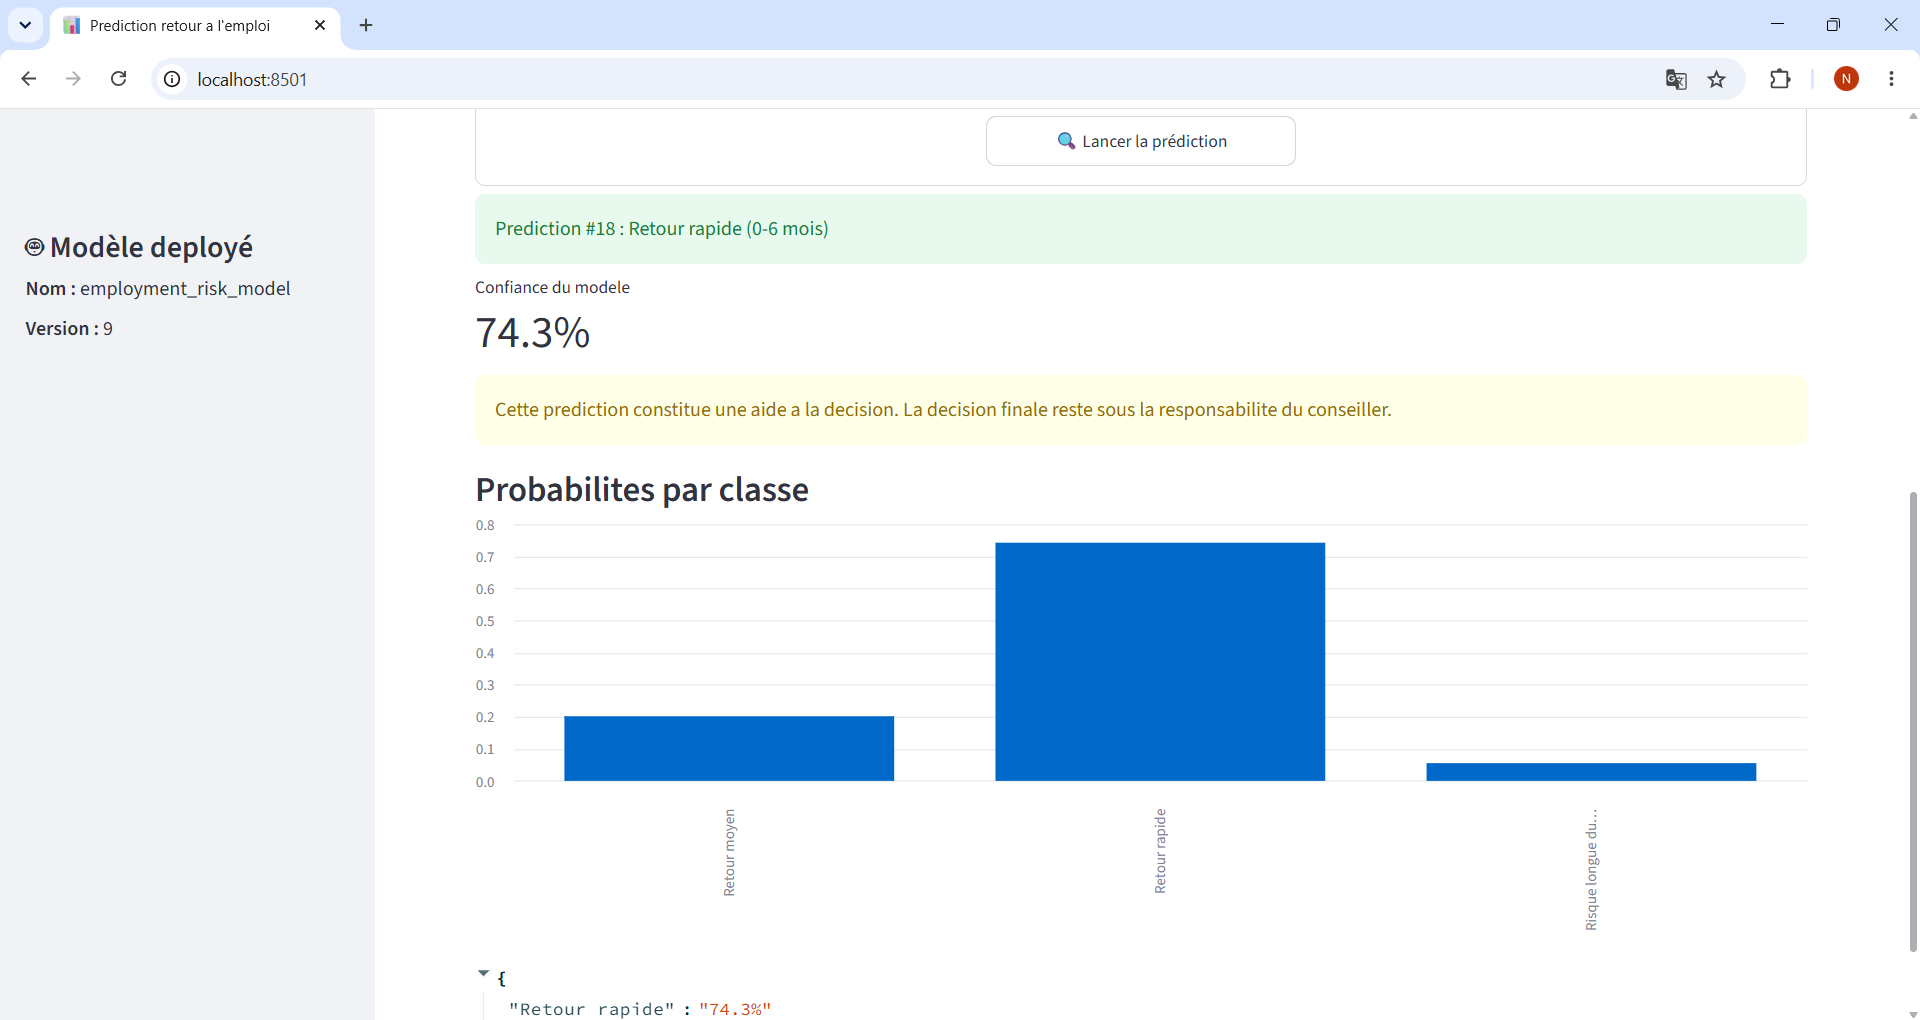

Affichage de l'historique :
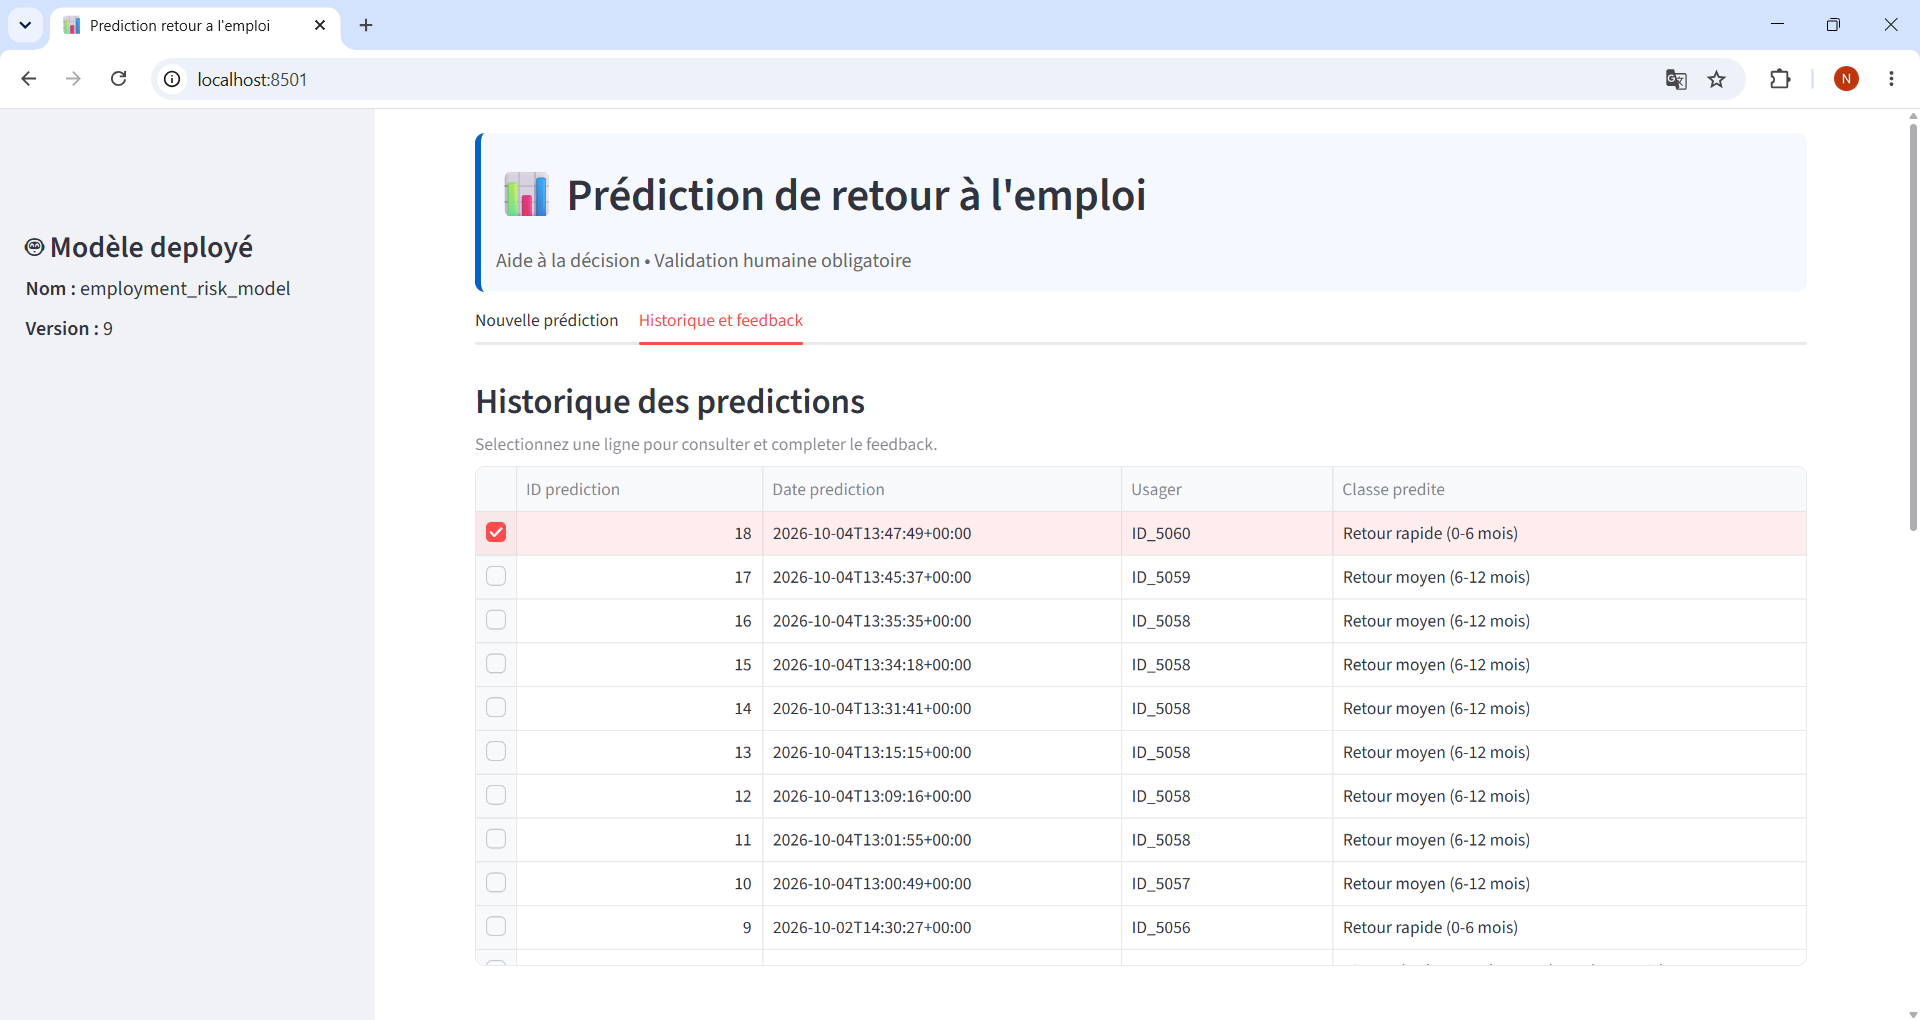

Formulaire de feedback :
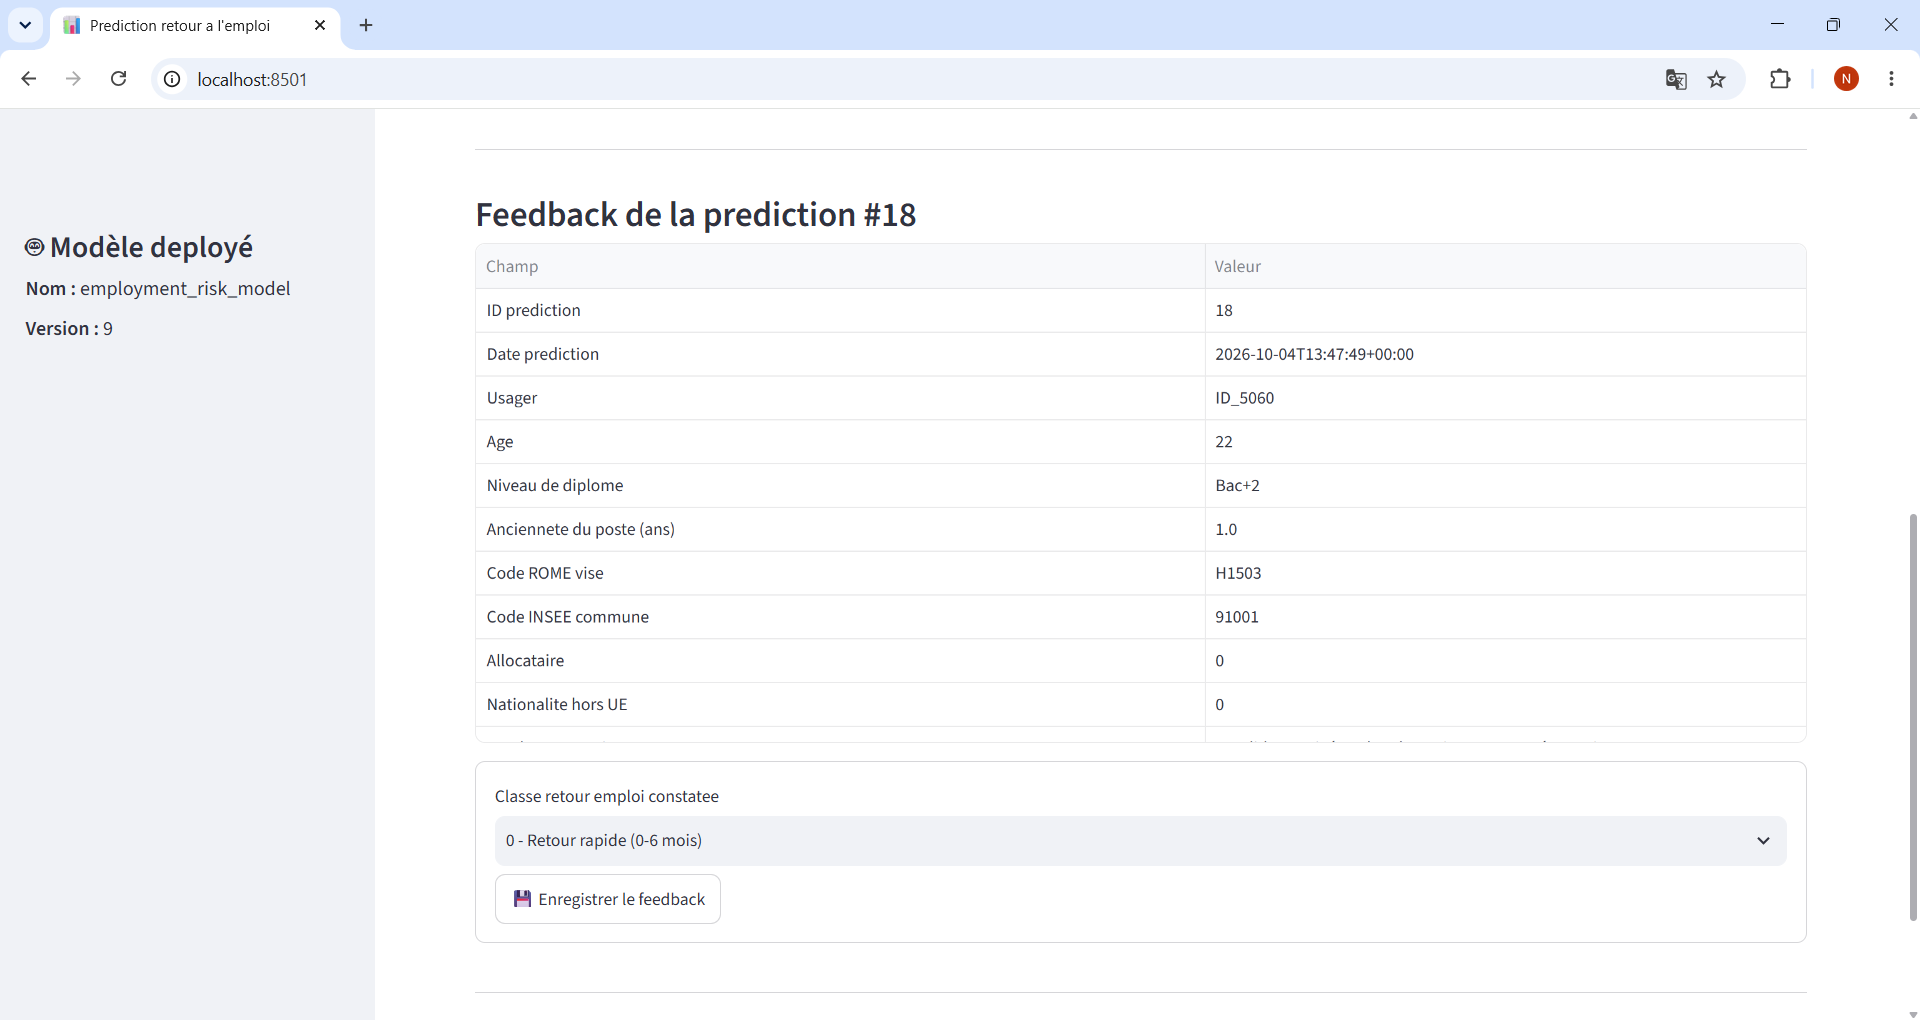

Export pour réentrainement :
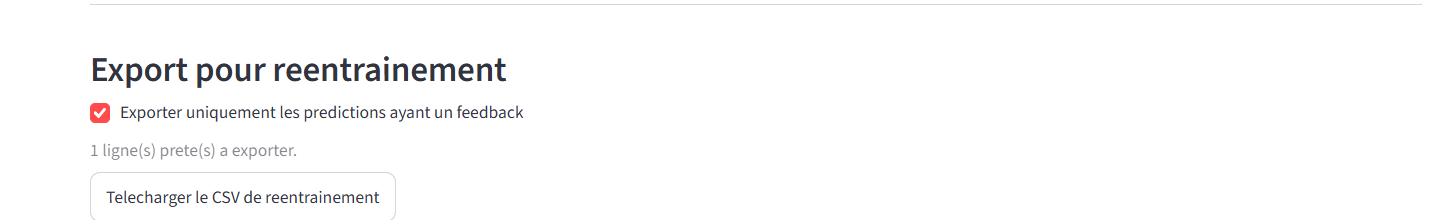


### 7.6 Conteneurisation

Lancement des conteneurs :

``` cmd
~/simplon-briefs/Atlas_CISIA_Exam/app$ docker compose up -d --build
WARN[0000] /home/a453784/simplon-briefs/Atlas_CISIA_Exam/app/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion
[+] Building 2.1s (22/22) FINISHED
 => [internal] load local bake definitions                                                                         0.0s
 => => reading from stdin 1.01kB                                                                                   0.0s
 => [api internal] load build definition from Dockerfile                                                           0.0s
 => => transferring dockerfile: 562B                                                                               0.0s
 => [streamlit internal] load build definition from Dockerfile                                                     0.0s
 => => transferring dockerfile: 458B                                                                               0.0s
 => [streamlit internal] load metadata for docker.io/library/python:3.12-slim                                      0.9s
 => [streamlit internal] load .dockerignore                                                                        0.0s
 => => transferring context: 2B                                                                                    0.0s
 => [api internal] load .dockerignore                                                                              0.0s
 => => transferring context: 2B                                                                                    0.0s
 => [streamlit 1/6] FROM docker.io/library/python:3.12-slim@sha256:dddfd7e07f9d15aeeca61529320492139d21cac7f0070c  0.0s
 => => resolve docker.io/library/python:3.12-slim@sha256:dddfd7e07f9d15aeeca61529320492139d21cac7f0070c00609243e5  0.0s
 => [api internal] load build context                                                                              0.0s
 => => transferring context: 93.85kB                                                                               0.0s
 => [streamlit internal] load build context                                                                        0.0s
 => => transferring context: 20.80kB                                                                               0.0s
 => CACHED [streamlit 2/6] WORKDIR /app                                                                            0.0s
 => CACHED [api 3/6] RUN apt-get update && apt-get install -y     build-essential     gcc     && rm -rf /var/lib/  0.0s
 => CACHED [api 4/6] COPY requirements.txt .                                                                       0.0s
 => CACHED [api 5/6] RUN pip install --no-cache-dir -r requirements.txt                                            0.0s
 => [api 6/6] COPY . .                                                                                             0.1s
 => CACHED [streamlit 3/6] COPY requirements.txt .                                                                 0.0s
 => CACHED [streamlit 4/6] RUN pip install --no-cache-dir -r requirements.txt                                      0.0s
 => [streamlit 5/6] COPY . .                                                                                       0.0s
 => [api] exporting to image                                                                                       0.3s
 => => exporting layers                                                                                            0.1s
 => => exporting manifest sha256:b6389eb8919f6355a8fdb17af0c4a1822d5357b70dfdf73ac1d8ed49b2dad7f0                  0.0s
 => => exporting config sha256:542907598e7754e289fca3b71071662b1c786226e522a86da579455597aa8e5d                    0.0s
 => => exporting attestation manifest sha256:18279764dc19984c8064507ffef3ce28faf014c255646dc28fad945e99160945      0.0s
 => => exporting manifest list sha256:b788010fad1bef0060743c02be7c1c7b04112ffb8c1a70996b34927f60ea56e2             0.0s
 => => naming to docker.io/library/app-api:latest                                                                  0.0s
 => => unpacking to docker.io/library/app-api:latest                                                               0.0s
 => [streamlit 6/6] RUN mkdir -p database                                                                          0.3s
 => [streamlit] exporting to image                                                                                 0.4s
 => => exporting layers                                                                                            0.2s
 => => exporting manifest sha256:99c0b68ae0a8b8def55ba9e0e75ff0bbd340ec1207ea47094bb142a2336744e2                  0.0s
 => => exporting config sha256:7cfd0100ffa043608dd68f23640c7bad88d04d54a641d1113efff37d1cace6b8                    0.0s
 => => exporting attestation manifest sha256:0488517d1aec90879e8805294587c83571ad288597c28c2952a0e14deb4ea98b      0.0s
 => => exporting manifest list sha256:d82641096d402fa5fd110ce9bb83a3b951414beac4f7df720c351f03ab7645ac             0.0s
 => => naming to docker.io/library/app-streamlit:latest                                                            0.0s
 => => unpacking to docker.io/library/app-streamlit:latest                                                         0.0s
 => [api] resolving provenance for metadata file                                                                   0.0s
 => [streamlit] resolving provenance for metadata file                                                             0.0s
[+] up 8/8
 ✔ Image app-streamlit        Built                                                                                 2.3s
 ✔ Image app-api              Built                                                                                 2.3s
 ✔ Network app_cisia_network  Created                                                                               0.0s
 ✔ Container cisia_mlflow     Started                                                                               0.7s
 ✔ Container cisia_api        Started                                                                               0.9s
 ✔ Container cisia_streamlit  Started                                                                               1.1s
 ✔ Container cisia_prometheus Started                                                                               1.1s
 ✔ Container cisia_grafana    Started    
```

Docker Compose Deskptop :

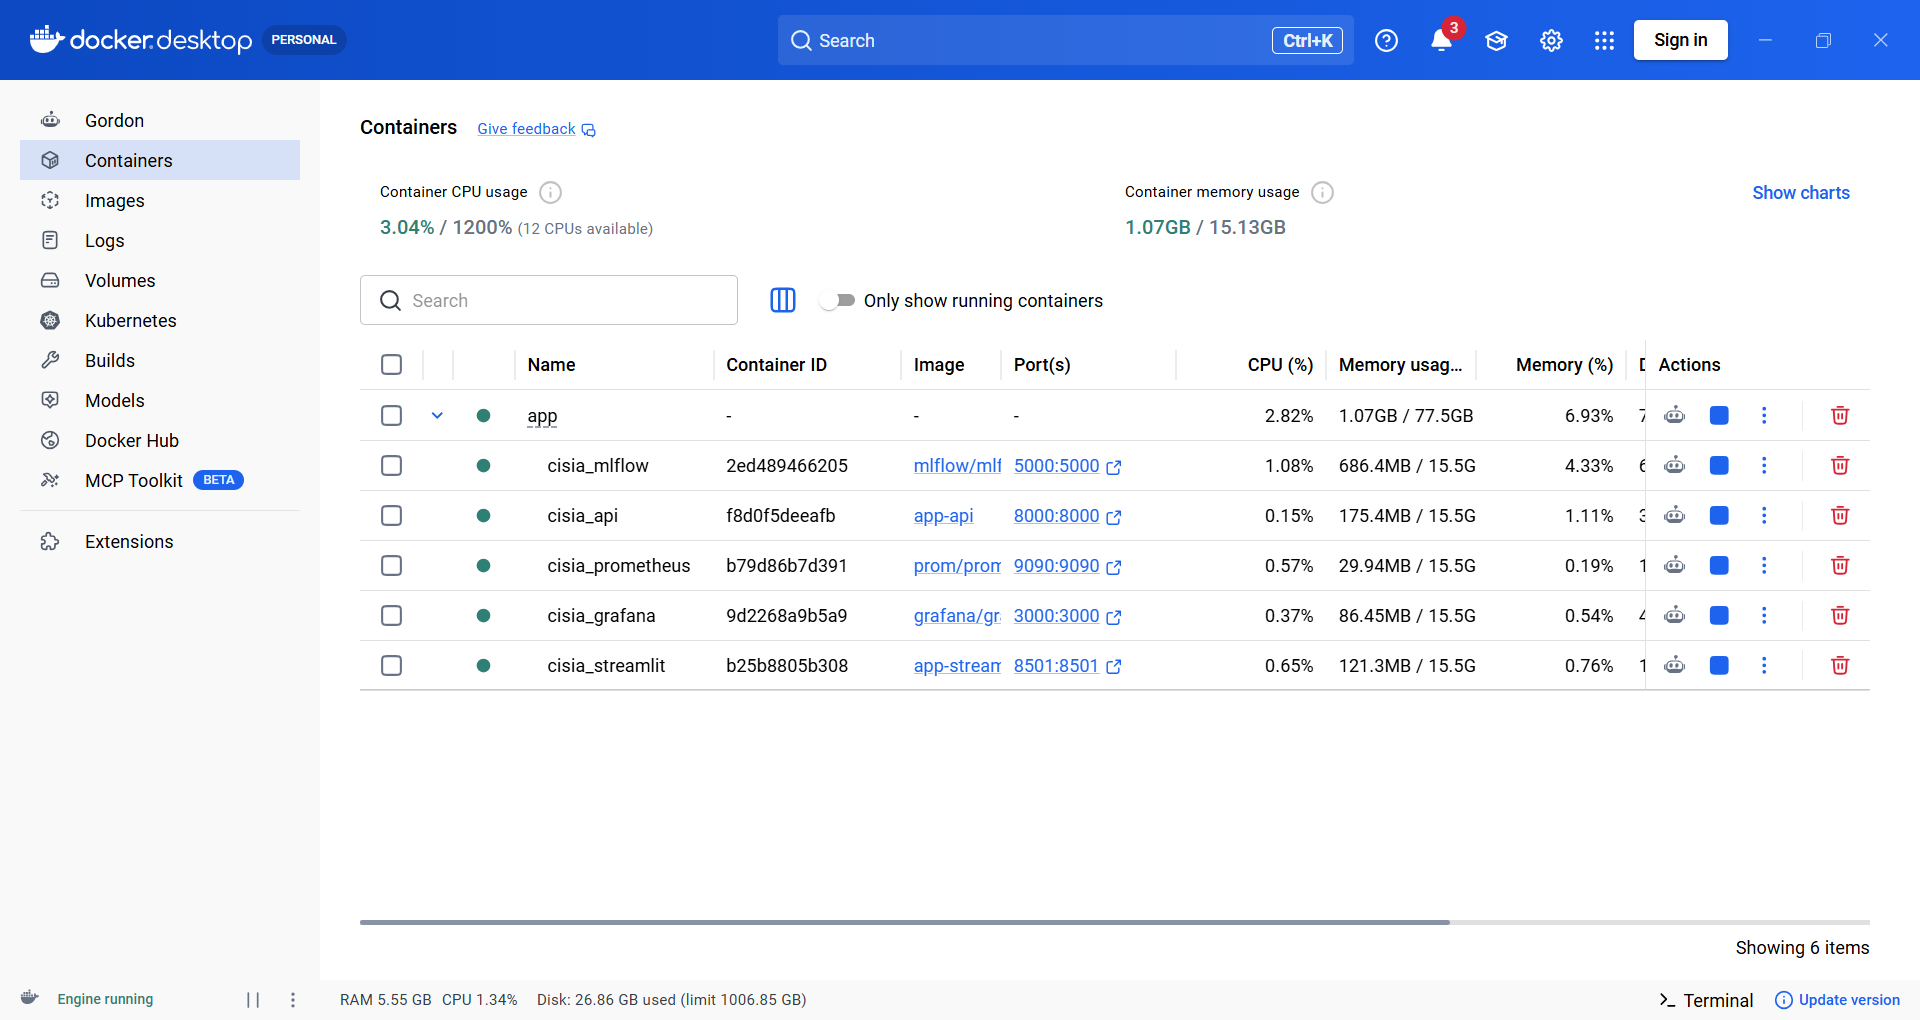


### 7.7 CI/CD

*[Inclure ici 1 capture workflow GitHub Actions (build → test → push). Captures d'écran d'un run CI vert. Liens vers les fichiers du repo.]*

GitHub Actions :
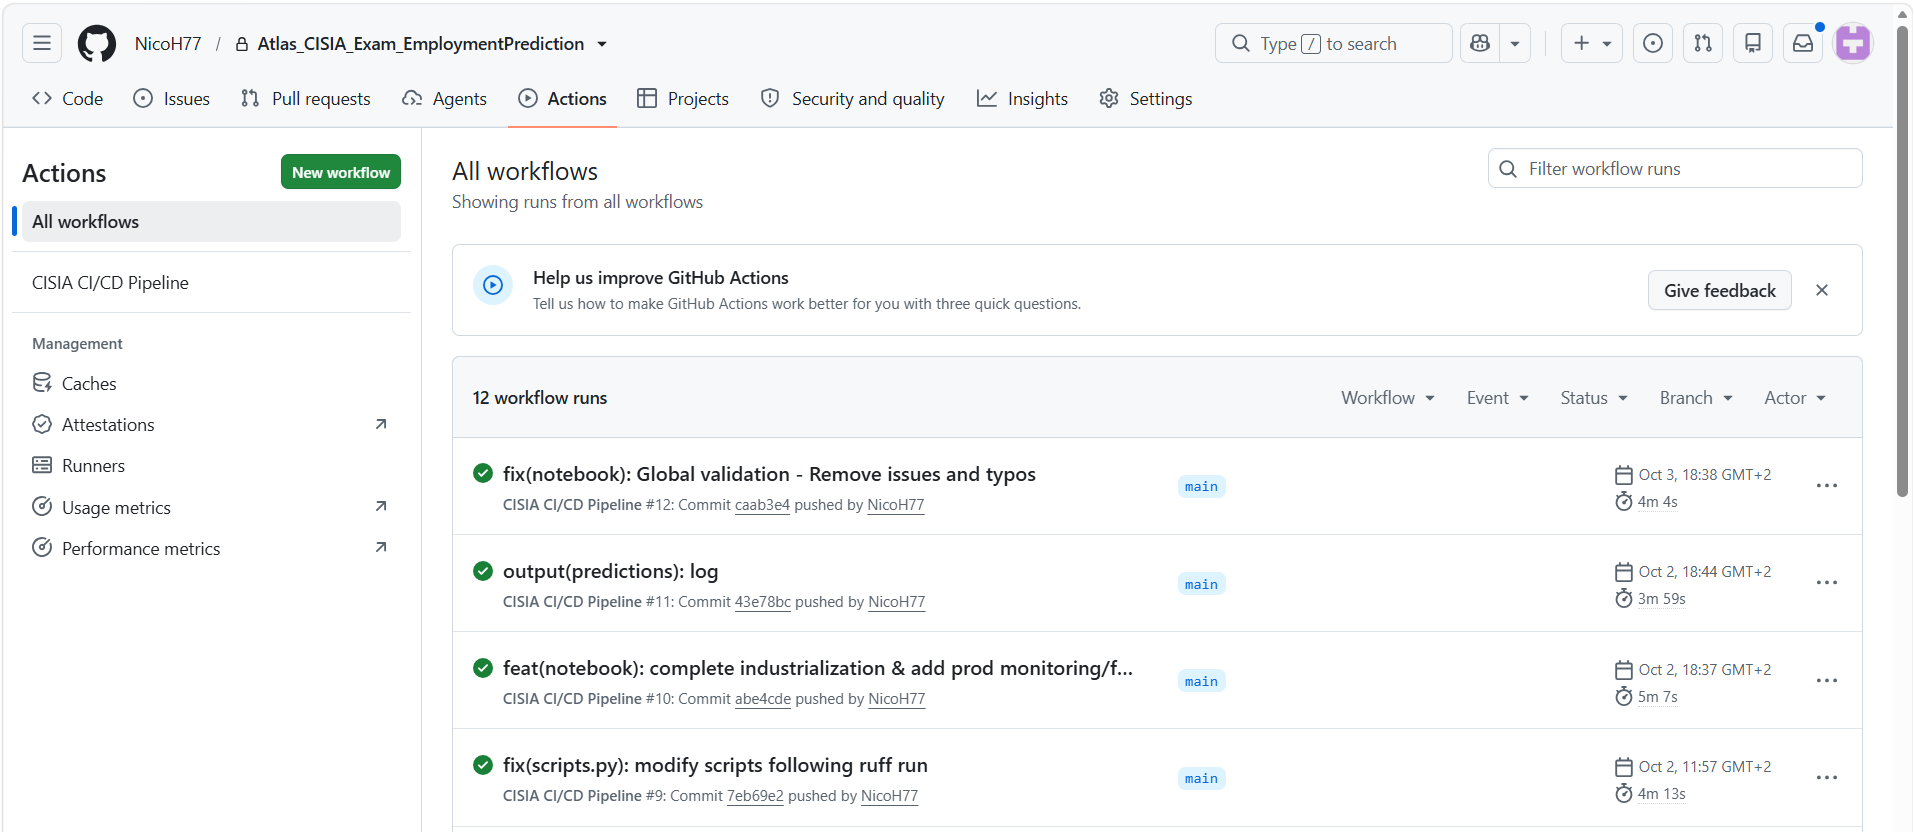

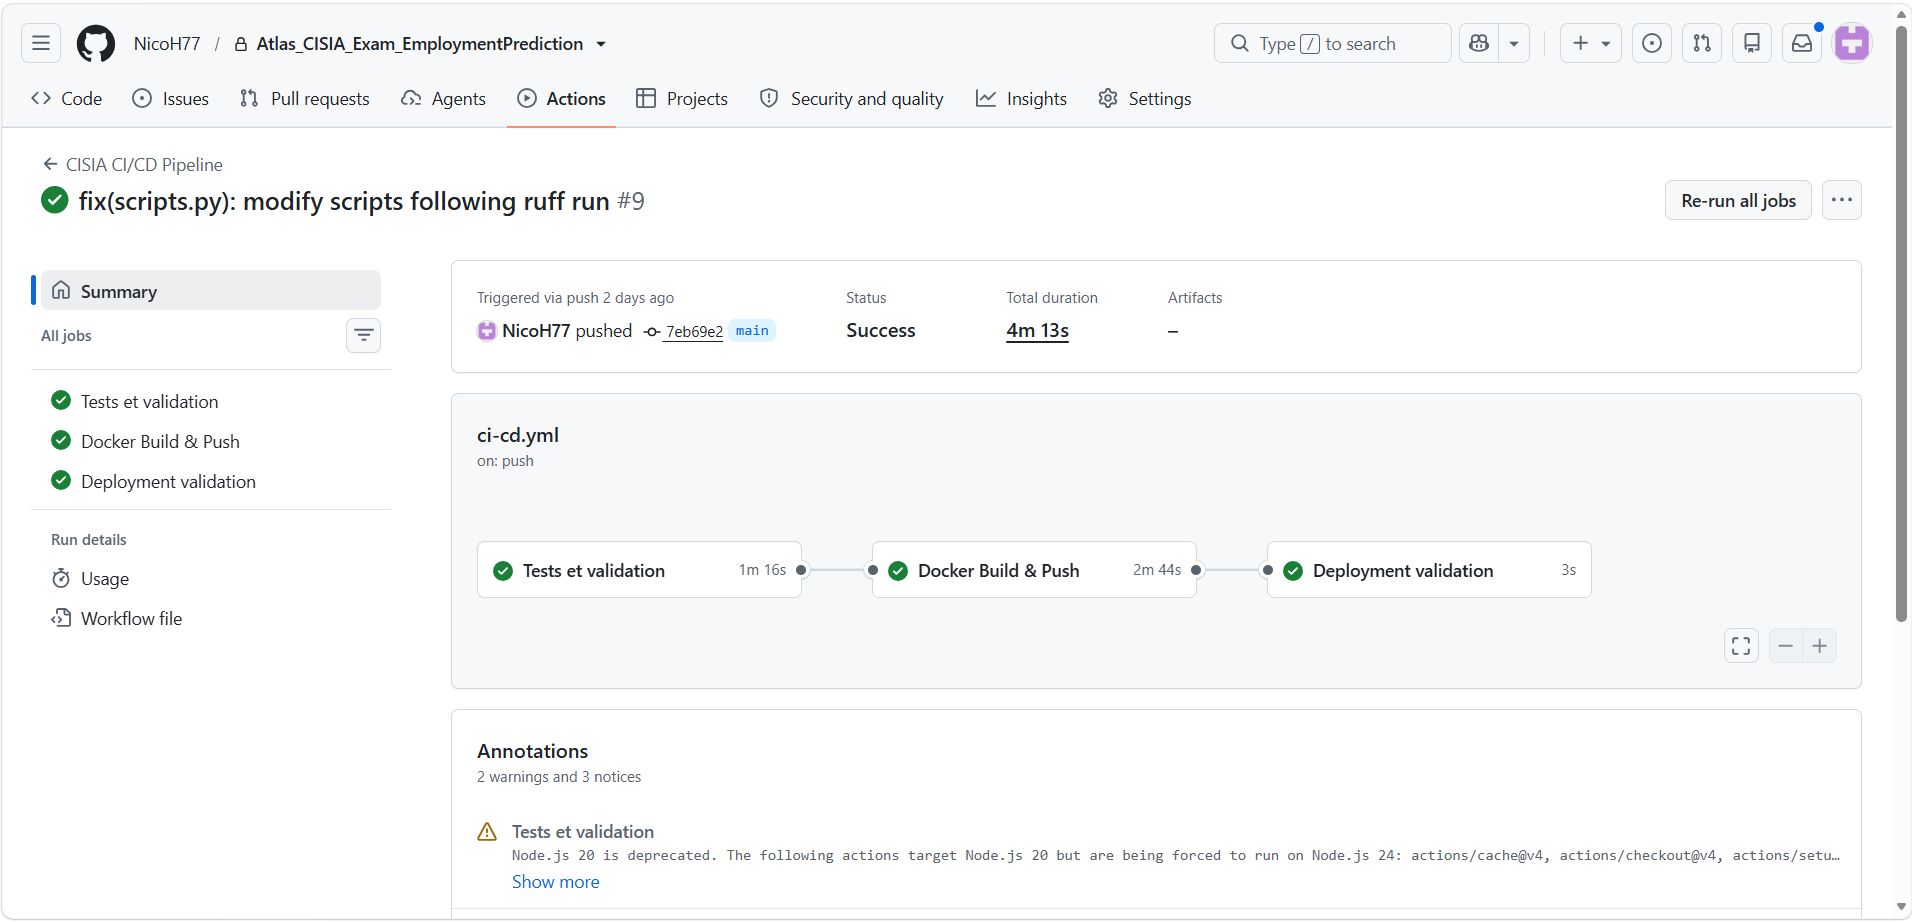


### 7.8 📝 Synthèse industrialisation

La solution a été industrialisée sous la forme d'une architecture composée d'une API FastAPI, d'une interface utilisateur Streamlit et d'un registre de modèles MLflow.

Chaque entraînement est tracé dans MLflow afin d'assurer la reproductibilité des résultats et le versionnement des modèles. Le modèle retenu est exposé via une API REST documentée par Swagger et déployée au sein d'un environnement conteneurisé Docker.

L'observabilité de la plateforme repose sur Prometheus et Grafana, permettant le suivi du service et la détection d'éventuelles anomalies. L'ensemble du code source est versionné dans GitHub et automatisé par GitHub Actions afin de garantir un processus de déploiement reproductible.

Cette architecture répond aux principales exigences de robustesse, de traçabilité et de maintenabilité attendues pour un déploiement en environnement réel.


## 8. Suivi en production & amélioration continue

principe : journalisation → drift → feedback → réentraînement

### 8.1 Monitoring

#### Niveau 1 : Monitoring technique
🎯 Garantir que le service d'IA reste disponible, performant et exploitable par les conseillers en conditions réelles.
- disponibilité API
- latence
- taux d'erreur

#### Niveau 2 : Monitoring données
🎯 Détecter une évolution des profils d'usagers ou de la qualité des données susceptible de rendre les prédictions moins fiables.
- PSI
- KS
- Chi²
- taux de valeurs manquantes

#### Niveau 3 : Monitoring métier
🎯 Vérifier que le modèle continue à produire des décisions utiles et cohérentes par rapport à la réalité observée sur le terrain.
- Accuracy
- Macro F1
- matrice de confusion
- taux de corrections humaines



### 8.2 Réentrainement et boucle de rétroaction

🎯 Améliorer continuellement les performances du modèle en intégrant les retours d'expérience et les nouvelles données validées.

L’application Streamlit implémente une boucle de rétroaction supervisée permettant de rapprocher les prédictions du modèle des classes effectivement constatées. 
- Chaque prédiction est historisée avec un identifiant unique, un horodatage, les variables d'entrée utilisées par le modèle, la classe prédite ainsi que les scores de confiance associés.
- Un conseiller (habilité) peut ensuite consulter l’historique et renseigner la classe réellement observée, sans modifier la prédiction initiale.
   + Cette séparation garantit la traçabilité de la décision algorithmique et de la correction humaine. 
- Les dossiers disposant d'un retour terrain validé peuvent être exportés sous forme de fichier CSV afin de constituer un jeu de données destiné à l'amélioration du modèle.
- Le réentraînement n’est pas déclenché automatiquement : les données doivent préalablement faire l’objet de contrôles de qualité, de représentativité, de biais et de conformité RGPD.
- Les nouveaux modèles entraînés sont ensuite évalués à l'aide des métriques définies dans le projet (Macro F1-Score, Recall Classe 2 et matrice de confusion) avant toute décision de déploiement en production. Cette étape garantit la stabilité des performances et limite le risque de dégradation du service rendu aux usagers.


```mermaid
flowchart TB

%% ==============================
%% ACTEURS
%% ==============================

subgraph ACT["👥 Parcours utilisateur"]
    direction LR
    C["🎯 Conseiller"]
end

%% ==============================
%% APPLICATION
%% ==============================

subgraph APP["🌐 Application IA"]
    direction LR

    ST["📊 Streamlit<br/>Interface utilisateur"]

    API["⚡ FastAPI<br/>/predict • /retrain"]

    MODEL["🧠 Modèle ML<br/>Production"]

    ST --> API
    API --> MODEL
end

%% ==============================
%% RESULTAT
%% ==============================

PRED["📈 Prédiction &<br/>Recommandation"]

%% ==============================
%% DONNEES
%% ==============================

subgraph DATA["🗄️ Données & Feedback"]
    direction TB

    DB["💾 Base SQLite"]

    FB["✍️ Feedback humain"]

    CSV["📄 Export CSV<br/>Réentraînement"]

    DB --> FB
    FB --> DB

    DB --> CSV
end

%% ==============================
%% MLOPS
%% ==============================

subgraph MLOPS["🚀 Gouvernance & Amélioration continue"]
    direction LR

    QUALIF["🔎 Contrôle qualité<br/>Biais IA<br/>RGPD"]

    TRAIN["🔄 Réentraînement"]

    VAL["✅ Validation<br/>Accuracy<br/>Macro-F1<br/>Matrice de confusion"]

    DEPLOY["📦 Déploiement<br/>Version N+1"]

    QUALIF --> TRAIN
    TRAIN --> VAL
    VAL --> DEPLOY
end

%% ==============================
%% FLUX
%% ==============================

C --> ST

MODEL --> PRED

PRED --> DB

CSV --> QUALIF

DEPLOY -. Promotion modèle .-> API

%% ==============================
%% STYLES
%% ==============================

style ACT fill:#E8F5E9,stroke:#43A047,stroke-width:2px
style APP fill:#E3F2FD,stroke:#1E88E5,stroke-width:2px
style DATA fill:#F3E5F5,stroke:#8E24AA,stroke-width:2px
style MLOPS fill:#FFF3E0,stroke:#FB8C00,stroke-width:2px

style PRED fill:#FFFFFF,stroke:#1E88E5,stroke-width:2px
```


---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*
- https://www.francetravail.org/files/live/sites/peorg/files/documents/Publications/Charte%20france%20travail%20IA%202025_DCE-jan25.pdf
- https://www.oecd.org/en/publications/statistical-profiling-in-public-employment-services_b5e5f16e-en.html
- European Commission: Directorate-General for Employment, Social Affairs and Inclusion, ICF and Pieterson, W., Opportunities of AI within PES processes and services – Exploring PES experiences, best practices and emerging business value, Publications Office of the European Union, 2025, https://data.europa.eu/doi/10.2767/84293

### D. Journal de bord



```mermaid
flowchart TB
        
        A["🎯 Cadrage métier<br/>Orientation et tri multimodal des demandeurs d'emploi par l'IA"]
        B["🗄️ Identification & acquisition des données<br/>dataset dataset_trajectoire_emploi.csv"]
        C["🔍 EDA<br/>(à compléter)"]
        A --> B --> C
        
    subgraph dataprep["⚙️ Préparation des données"]
        direction LR
        D["Préparation des features<br/>(à compléter)"]
        E["Train/Test split<br/>(à compléter)"]
        F["INstanciation du pipeline<br/>(à compléter)"]
        
        D --> E --> F
    end

    subgraph trainmodel["🤖 Modélisation & entrainement"]
        direction LR
        G["Sélection des modèles"]
        H["Validation croisée"]
        I["Benchmark des modèles sélectionnés"]
        J["Optimisation du meilleur modèle"]
        K["Evaluation finale"]
        
        G --> H --> I --> J --> K
    end
    
    L["⚖️ Analyse des scénarios & arbitrage<br/>(à compléter)"]
        
    subgraph indus["🚀 Industrialisation"]
        direction LR
        M["Tracking & Registry ML flow"]
        N["API Fast API"]
        O["Interface Utilisateur"]
        P["Orchestration Docker Compose"]
        Q["CI/CD"]

        M --> N --> O --> P --> Q
    end

    subgraph monitor["🔄 Amélioration continue"]
        direction LR
        R["Monitoring"]
        S["Boucle de rétroaction"]
        T["Réentrainement"]

        R --> S --> T
    end


    C--> dataprep
    dataprep --> trainmodel
    trainmodel --> L
    L --> indus
    indus --> monitor
    
    style dataprep fill:#e8f4ff,stroke:#2b7bce
    style trainmodel fill:#f7f7f7,stroke:#bbb
    style indus fill:#e8f4ff,stroke:#2b7bce
    style monitor fill:#f7f7f7,stroke:#bbb
```

```mermaid

flowchart LR

%% =====================
%% BACKEND
%% =====================

subgraph BACKEND["🖥️ Backend"]
    direction LR

    MODEL["🤖<br/>Modèle entraîné"]

    MLFLOW["📦<br/>MLflow<br/><br/>Tracking & Registry"]

    FASTAPI["⚡<br/>FastAPI<br/><br/>/predict<br/>/retrain"]

    MODEL --> MLFLOW
    MLFLOW --> FASTAPI
end

%% =====================
%% FRONTEND
%% =====================

subgraph FRONTEND["🌐 Frontend"]
    STREAMLIT["📊<br/>Streamlit<br/><br/>Interface utilisateur"]
end

FASTAPI -- champion --> STREAMLIT

%% =====================
%% INFRA
%% =====================

subgraph DOCKER["🐳 Réseau Docker Compose"]
    direction LR

    subgraph BC["Backend Container"]
        direction TB
        BC1["MLflow"]
        BC2["FastAPI"]
    end

    subgraph FC["Frontend Container"]
        direction TB
        FC1["Streamlit"]
    end

    BC <-.-> FC
end

MLFLOW -. Déployé .-> BC
FASTAPI -. Déployé .-> BC
STREAMLIT -. Déployé .-> FC

%% =====================
%% MONITORING
%% =====================

subgraph OBS["📈 Monitoring"]
    direction LR

    PROM["Prometheus"]
    GRAF["Grafana"]

    PROM --> GRAF
end

FASTAPI --> PROM

%% =====================
%% STYLES
%% =====================

style BACKEND fill:#F4E1D5,stroke:#D98D5B,stroke-width:2px
style FRONTEND fill:#D7E8C5,stroke:#7BA05B,stroke-width:2px
style DOCKER fill:#ffffff,stroke:#000000,stroke-dasharray: 5 5
style OBS fill:#E6F3FF,stroke:#4A90E2
```